# 01 · Data Acquisition & Preparation

**Project — Forecasting local COVID-19 infection dynamics in Israel, and whether
socio-economic structure adds predictive information.**

Two independent sources are acquired, cleaned and joined here:

| # | source | grain | role |
|---|--------|-------|------|
| 1 | `data/raw/geographic-sum-per-day-ver_00859.csv` — Israeli MoH open data | one row per locality / statistical-area **per day** | dynamic epidemiology (cases, tests, hospitalisations, vaccination) |
| 2 | `data/raw/mifkad_2.csv` — 2022 Israeli Census (Lamas) | one row per statistical area (**static**) | socio-economic / demographic structure |

The shared key is `City_agas_code = <locality_code>_<statistical_area>` (`_0` = whole city).

Outputs written by this notebook (canonical processed files, consumed by 02–05):

* `data/processed/Corona_loc_processed.csv` — clean daily panel
* `data/processed/models/wave2_ir_severity_table.csv` — wave-2 cross-sectional targets
* `data/processed/mifkad/Mifkad_2_reduced.csv` — 27 census features (from 70 raw columns)
* `data/processed/models/wave2_model_table.csv` — wave-2 targets ✕ census (input to notebook 03)
* `data/processed/Corona_Mifkad2_merged.csv` — full daily panel ✕ census (input to notebook 02)

In [1]:
# --- repo bootstrap: make every path in this notebook repo-relative ---
import os
from pathlib import Path

PROJECT_ROOT = Path.cwd()
while not (PROJECT_ROOT / "data" / "raw").exists() and PROJECT_ROOT != PROJECT_ROOT.parent:
    PROJECT_ROOT = PROJECT_ROOT.parent
assert (PROJECT_ROOT / "data" / "raw").exists(), "launch this notebook from inside the repo"
os.chdir(PROJECT_ROOT)
print("PROJECT_ROOT =", PROJECT_ROOT)

PROJECT_ROOT = /home/bcrlab/igguest/porat_naama


## 1.1 · COVID-19 daily geographic panel

Raw MoH file → one clean row per `City_agas_code` per date.

Key cleaning decisions (all deliberate, flagged rather than silent):

* **`'<15'` privacy-censored counts → `0`** (small-count suppression in the source).
* **Accumulated → daily** via per-area `.diff()`; negative diffs (retro-active
  data corrections) are treated as `0`.
* **Adaptive infection rate** — `infection_rate = new_cases / new_tests`, but if a
  single day has `< 30` tests the window is widened backward up to 14 days until
  enough tests accumulate. Without this, low-testing days produce meaningless
  0/near-0 rates. `inf` values are set to `NaN`.
* **Whole-city `_0` rows** are synthesised (sum of a locality's sub-areas) where missing.
* **`is_lockdown`** flag from the four official national lockdown windows.
* Backward-looking **lag (1,2,3,7,14 d)** and **rolling-mean (7,14,28 d)** features,
  computed **per area** (never across areas).

In [2]:
from pathlib import Path
import pandas as pd
import numpy as np

RAW_PATH = Path("data/raw/geographic-sum-per-day-ver_00859.csv")
OUT_PATH = Path("data/processed/covid_clean.parquet")

df_loc_corona = pd.read_csv(RAW_PATH).copy()
(df_loc_corona == '<15').any().any()

np.True_

In [3]:
df_loc_corona.replace('<15', 0, inplace=True)
print((df_loc_corona == '<15').any().any())
df_loc_corona = df_loc_corona.fillna(0)
df_loc_corona.head()

False


,town_code,agas_code,town,date,accumulated_cases,new_cases_on_date,accumulated_recoveries,new_recoveries_on_date,accumulated_hospitalized,new_hospitalized_on_date,accumulated_deaths,new_deaths_on_date,accumulated_diagnostic_tests,new_diagnostic_tests_on_date,accumulated_vaccination_first_dose,new_vacc_first_dose_on_date,accumulated_vaccination_second_dose,new_vacc_second_dose_on_date,accumulated_vaccination_third_dose,new_vacc_third_dose_on_date
0,26,0.0,ראש פינה,2020-03-11,0,False,0,False,0.0,False,0,False,0,False,0.0,False,0.0,False,0.0,False
1,26,0.0,ראש פינה,2020-03-12,0,False,0,False,0.0,False,0,False,0,False,0.0,False,0.0,False,0.0,False
2,26,0.0,ראש פינה,2020-03-13,0,False,0,False,0.0,False,0,False,0,False,0.0,False,0.0,False,0.0,False
3,26,0.0,ראש פינה,2020-03-14,0,False,0,False,0.0,False,0,False,0,False,0.0,False,0.0,False,0.0,False
4,26,0.0,ראש פינה,2020-03-15,0,False,0,False,0.0,False,0,False,0,False,0.0,False,0.0,False,0.0,False


In [4]:
# This cell removes agas_code = 0 for towns that also have specific non-zero statistical areas,
# keeps agas_code = 0 when it is the town's only statistical area,
# and creates a unique City_agas_code identifier (town_code + agas_code).

df_loc_corona['agas_code'] = df_loc_corona['agas_code'].astype(int)

# Identify towns that have at least one non-zero agas_code
towns_with_real_agas = df_loc_corona.loc[
    df_loc_corona['agas_code'] != 0,
    'town_code'
].unique()

# Drop agas_code == 0 only for towns that also have non-zero agas codes
df_loc_corona = df_loc_corona[
    ~(
        (df_loc_corona['agas_code'] == 0) &
        (df_loc_corona['town_code'].isin(towns_with_real_agas))
    )
].copy()

# Create combined city + statistical-area code
df_loc_corona['City_agas_code'] = (
    df_loc_corona['town_code'].astype(str)
    + "_"
    + df_loc_corona['agas_code'].astype(str)
)

df_loc_corona = df_loc_corona.set_index('City_agas_code')

df_loc_corona.head()

,town_code,agas_code,town,date,accumulated_cases,new_cases_on_date,accumulated_recoveries,new_recoveries_on_date,accumulated_hospitalized,new_hospitalized_on_date,accumulated_deaths,new_deaths_on_date,accumulated_diagnostic_tests,new_diagnostic_tests_on_date,accumulated_vaccination_first_dose,new_vacc_first_dose_on_date,accumulated_vaccination_second_dose,new_vacc_second_dose_on_date,accumulated_vaccination_third_dose,new_vacc_third_dose_on_date
City_agas_code,,,,,,,,,,,,,,,,,,,,
26_0,26,0,ראש פינה,2020-03-11,0,False,0,False,0.0,False,0,False,0,False,0.0,False,0.0,False,0.0,False
26_0,26,0,ראש פינה,2020-03-12,0,False,0,False,0.0,False,0,False,0,False,0.0,False,0.0,False,0.0,False
26_0,26,0,ראש פינה,2020-03-13,0,False,0,False,0.0,False,0,False,0,False,0.0,False,0.0,False,0.0,False
26_0,26,0,ראש פינה,2020-03-14,0,False,0,False,0.0,False,0,False,0,False,0.0,False,0.0,False,0.0,False
26_0,26,0,ראש פינה,2020-03-15,0,False,0,False,0.0,False,0,False,0,False,0.0,False,0.0,False,0.0,False


In [5]:
# This cell verifies that no town still contains both agas_code = 0 and non-zero agas codes.
# These should be empty: no town should have both x_0 and x_nonzero
check = (
    df_loc_corona.reset_index()
    .groupby('town_code')['agas_code']
    .agg(lambda x: (0 in x.values) and (x != 0).any())
)

print("Towns still containing both 0 and non-zero agas codes:")
print(check[check].index.tolist())

Towns still containing both 0 and non-zero agas codes:
[]


In [6]:
accumulated_cols = ['accumulated_cases', 'accumulated_recoveries', 'accumulated_hospitalized', 'accumulated_deaths', 'accumulated_diagnostic_tests', 'accumulated_vaccination_first_dose', 'accumulated_vaccination_second_dose', 'accumulated_vaccination_third_dose']
new_on_date_cols = ['new_cases_on_date', 'new_recoveries_on_date', 'new_hospitalized_on_date', 'new_deaths_on_date', 'new_diagnostic_tests_on_date', 'new_vacc_first_dose_on_date', 'new_vacc_second_dose_on_date', 'new_vacc_third_dose_on_date']

for col in accumulated_cols:
    df_loc_corona[col] = pd.to_numeric(df_loc_corona[col], errors='coerce').fillna(0).astype(int)

df_loc_corona = df_loc_corona.reset_index()
df_loc_corona['is_city_aggregate'] = 0

existing_city_codes = set(df_loc_corona['City_agas_code'])
towns_missing_city_row = sorted(
    t for t in df_loc_corona['town_code'].unique() if f"{t}_0" not in existing_city_codes
)

sub_rows = df_loc_corona[df_loc_corona['town_code'].isin(towns_missing_city_row)]
agg_dict = {**{c: 'sum' for c in accumulated_cols}, **{c: 'max' for c in new_on_date_cols}, 'town': 'first'}
city_agg = sub_rows.groupby(['town_code', 'date'], as_index=False).agg(agg_dict)
city_agg['agas_code'] = 0
city_agg['City_agas_code'] = city_agg['town_code'].astype(str) + "_0"
city_agg['is_city_aggregate'] = 1

df_loc_corona = pd.concat([df_loc_corona, city_agg], ignore_index=True)
df_loc_corona = df_loc_corona.sort_values(['City_agas_code', 'date']).set_index('City_agas_code')

print(f"Towns synthesized: {len(towns_missing_city_row)}")
print(f"Rows added: {len(city_agg)}")
print(f"New df.shape: {df_loc_corona.shape}")
print(f"Unique agas_code values: {sorted(df_loc_corona['agas_code'].unique())}")

Towns synthesized: 81
Rows added: 95094
New df.shape: (1942906, 21)
Unique agas_code values: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(16), np.int64(17), np.int64(18), np.int64(19), np.int64(21), np.int64(22), np.int64(23), np.int64(24), np.int64(25), np.int64(26), np.int64(27), np.int64(28), np.int64(31), np.int64(32), np.int64(33), np.int64(34), np.int64(35), np.int64(36), np.int64(37), np.int64(38), np.int64(41), np.int64(42), np.int64(43), np.int64(44), np.int64(45), np.int64(51), np.int64(52), np.int64(53), np.int64(54), np.int64(55), np.int64(56), np.int64(57), np.int64(61), np.int64(62), np.int64(63), np.int64(64), np.int64(65), np.int64(66), np.int64(111), np.int64(112), np.int64(113), np.int64(114), np.int64(115), np.int64(116), np.int64(117), np.int64(121), np.int64(122), np.int64(123), np.int64(1

In [7]:
df_loc_corona = df_loc_corona.drop(columns=['new_cases_on_date', 'new_recoveries_on_date', 'new_hospitalized_on_date', 'new_deaths_on_date', 'new_diagnostic_tests_on_date', 'new_vacc_first_dose_on_date', 'new_vacc_second_dose_on_date', 'new_vacc_third_dose_on_date'])
df_loc_corona = df_loc_corona.drop(columns=['town_code','agas_code'])
df_loc_corona = df_loc_corona.sort_values(['City_agas_code', 'date'])
df_loc_corona.head()

,town,date,accumulated_cases,accumulated_recoveries,accumulated_hospitalized,accumulated_deaths,accumulated_diagnostic_tests,accumulated_vaccination_first_dose,accumulated_vaccination_second_dose,accumulated_vaccination_third_dose,is_city_aggregate
City_agas_code,,,,,,,,,,,
1015_0,מבשרת ציון,2020-03-11,0,0,0,0,0,0,0,0,1
1015_0,מבשרת ציון,2020-03-12,0,0,0,0,0,0,0,0,1
1015_0,מבשרת ציון,2020-03-13,0,0,0,0,0,0,0,0,1
1015_0,מבשרת ציון,2020-03-14,0,0,0,0,0,0,0,0,1
1015_0,מבשרת ציון,2020-03-15,0,0,0,0,0,0,0,0,1


In [8]:
columns_to_convert = ['accumulated_cases', 'accumulated_recoveries', 'accumulated_hospitalized', 'accumulated_deaths', 'accumulated_diagnostic_tests', 'accumulated_vaccination_first_dose', 'accumulated_vaccination_second_dose', 'accumulated_vaccination_third_dose']
for column in columns_to_convert:
    # Convert to numeric first, then cast to integer
    df_loc_corona[column] = pd.to_numeric(df_loc_corona[column], errors='coerce').fillna(0).astype(int)
df_loc_corona.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1942906 entries, 1015_0 to 99_0
Data columns (total 11 columns):
 #   Column                               Dtype 
---  ------                               ----- 
 0   town                                 object
 1   date                                 object
 2   accumulated_cases                    int64 
 3   accumulated_recoveries               int64 
 4   accumulated_hospitalized             int64 
 5   accumulated_deaths                   int64 
 6   accumulated_diagnostic_tests         int64 
 7   accumulated_vaccination_first_dose   int64 
 8   accumulated_vaccination_second_dose  int64 
 9   accumulated_vaccination_third_dose   int64 
 10  is_city_aggregate                    int64 
dtypes: int64(9), object(2)
memory usage: 177.9+ MB


In [9]:
df_loc_corona = df_loc_corona.copy()

# (also important: sort before diff)
df_loc_corona = df_loc_corona.sort_values(["City_agas_code", "date"])

df_loc_corona["positive_daily"]      = df_loc_corona.groupby("City_agas_code")["accumulated_cases"].diff()
df_loc_corona["hospitalized_daily"]  = df_loc_corona.groupby("City_agas_code")["accumulated_hospitalized"].diff()
df_loc_corona["tested_daily"]        = df_loc_corona.groupby("City_agas_code")["accumulated_diagnostic_tests"].diff()

df_loc_corona["infection_rate"]   = df_loc_corona["positive_daily"] / df_loc_corona["tested_daily"]
df_loc_corona["recovery_ratio"]   = df_loc_corona["accumulated_recoveries"] / df_loc_corona["accumulated_cases"]
df_loc_corona["recovery_index"]   = df_loc_corona["accumulated_recoveries"] / df_loc_corona["accumulated_diagnostic_tests"]

# Replace inf/-inf -> NaN, then decide how to fill
df_loc_corona["infection_rate"] = df_loc_corona["infection_rate"].replace([np.inf, -np.inf], np.nan)

# Now choose fill policy
df_loc_corona = df_loc_corona.fillna(0)
df_loc_corona.tail()

,town,date,accumulated_cases,accumulated_recoveries,accumulated_hospitalized,accumulated_deaths,accumulated_diagnostic_tests,accumulated_vaccination_first_dose,accumulated_vaccination_second_dose,accumulated_vaccination_third_dose,is_city_aggregate,positive_daily,hospitalized_daily,tested_daily,infection_rate,recovery_ratio,recovery_index
City_agas_code,,,,,,,,,,,,,,,,,
99_0,מצפה רמון,2023-05-24,2676,2666,34,0,32481,3545,3323,2521,0,0.0,0.0,0.0,0.0,0.996263,0.082079
99_0,מצפה רמון,2023-05-25,2676,2666,34,0,32481,3545,3323,2521,0,0.0,0.0,0.0,0.0,0.996263,0.082079
99_0,מצפה רמון,2023-05-26,2676,2666,34,0,32481,3545,3323,2521,0,0.0,0.0,0.0,0.0,0.996263,0.082079
99_0,מצפה רמון,2023-05-27,2676,2666,34,0,32482,3545,3323,2521,0,0.0,0.0,1.0,0.0,0.996263,0.082076
99_0,מצפה רמון,2023-05-28,2676,2666,34,0,32482,3545,3323,2521,0,0.0,0.0,0.0,0.0,0.996263,0.082076


In [10]:
# ============================================================
# Adaptive infection rate
# If too few tests were performed on a single day,
# expand the window backward until enough tests accumulate.
# ============================================================

MIN_TESTS = 30
MAX_WINDOW_DAYS = 14

# Keep the original 1-day calculation for comparison/debugging
df_loc_corona["infection_rate_daily_raw"] = df_loc_corona["infection_rate"]

# Final adaptive values
df_loc_corona["infection_rate_adaptive"] = np.nan
df_loc_corona["infection_rate_window_days"] = np.nan
df_loc_corona["infection_rate_tests_used"] = np.nan
df_loc_corona["infection_rate_cases_used"] = np.nan

# Make sure date is datetime
df_loc_corona["date"] = pd.to_datetime(df_loc_corona["date"])

grouped = df_loc_corona.groupby("City_agas_code", sort=False)

# Try windows of 1 day, 2 days, ..., up to MAX_WINDOW_DAYS
for lag in range(1, MAX_WINDOW_DAYS + 1):

    prev_cases = grouped["accumulated_cases"].shift(lag)
    prev_tests = grouped["accumulated_diagnostic_tests"].shift(lag)
    prev_date = grouped["date"].shift(lag)

    cases_in_window = (
        df_loc_corona["accumulated_cases"] - prev_cases
    )

    tests_in_window = (
        df_loc_corona["accumulated_diagnostic_tests"] - prev_tests
    )

    actual_window_days = (
        df_loc_corona["date"] - prev_date
    ).dt.days

    # Only assign rows that have not already found a suitable window
    not_assigned = df_loc_corona["infection_rate_adaptive"].isna()

    # A usable window must:
    # 1. contain at least MIN_TESTS tests
    # 2. have non-negative case/test differences
    # 3. not imply more cases than tests
    # 4. stay within MAX_WINDOW_DAYS
    valid = (
        not_assigned
        & (tests_in_window >= MIN_TESTS)
        & (cases_in_window >= 0)
        & (cases_in_window <= tests_in_window)
        & (actual_window_days >= 1)
        & (actual_window_days <= MAX_WINDOW_DAYS)
    )

    df_loc_corona.loc[valid, "infection_rate_adaptive"] = (
        cases_in_window[valid] / tests_in_window[valid]
    )

    df_loc_corona.loc[valid, "infection_rate_window_days"] = (
        actual_window_days[valid]
    )

    df_loc_corona.loc[valid, "infection_rate_tests_used"] = (
        tests_in_window[valid]
    )

    df_loc_corona.loc[valid, "infection_rate_cases_used"] = (
        cases_in_window[valid]
    )


# Replace the old infection_rate with the adaptive version
df_loc_corona["infection_rate"] = df_loc_corona["infection_rate_adaptive"]


# ============================================================
# Diagnostics
# ============================================================

print("Adaptive infection-rate calculation")
print("-----------------------------------")
print(f"Minimum tests required: {MIN_TESTS}")
print(f"Maximum window:         {MAX_WINDOW_DAYS} days")

print(
    "\nRows with a usable infection rate:",
    f"{df_loc_corona['infection_rate'].notna().sum():,}",
    f"({df_loc_corona['infection_rate'].notna().mean()*100:.2f}%)"
)

print(
    "Rows still unresolved:",
    f"{df_loc_corona['infection_rate'].isna().sum():,}",
    f"({df_loc_corona['infection_rate'].isna().mean()*100:.2f}%)"
)

print(
    "Rows with infection_rate > 1:",
    f"{(df_loc_corona['infection_rate'] > 1).sum():,}"
)

print("\nWindow lengths used:")
print(
    df_loc_corona["infection_rate_window_days"]
    .value_counts(dropna=False)
    .sort_index()
)

Adaptive infection-rate calculation
-----------------------------------
Minimum tests required: 30
Maximum window:         14 days

Rows with a usable infection rate: 1,660,817 (85.48%)
Rows still unresolved: 282,089 (14.52%)
Rows with infection_rate > 1: 0

Window lengths used:
infection_rate_window_days
1.0     509558
2.0     346097
3.0     202508
4.0     134088
5.0      95875
6.0      74331
7.0      60138
8.0      49769
9.0      43333
10.0     37734
11.0     32804
12.0     28617
13.0     24580
14.0     21385
NaN     282089
Name: count, dtype: int64


In [11]:
df_loc_corona['is_lockdown'] = 0
df_loc_corona['date']= pd.to_datetime(df_loc_corona['date'])
df_loc_corona.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1942906 entries, 1015_0 to 99_0
Data columns (total 23 columns):
 #   Column                               Dtype         
---  ------                               -----         
 0   town                                 object        
 1   date                                 datetime64[ns]
 2   accumulated_cases                    int64         
 3   accumulated_recoveries               int64         
 4   accumulated_hospitalized             int64         
 5   accumulated_deaths                   int64         
 6   accumulated_diagnostic_tests         int64         
 7   accumulated_vaccination_first_dose   int64         
 8   accumulated_vaccination_second_dose  int64         
 9   accumulated_vaccination_third_dose   int64         
 10  is_city_aggregate                    int64         
 11  positive_daily                       float64       
 12  hospitalized_daily                   float64       
 13  tested_daily                  

In [12]:
#lockdown dates:
#March 19, 2020 – April 24, 2020
#September 18, 2020 – October 18, 2020
#December 27, 2020 – February 6, 2021
#July 29, 2021 – November 27, 2021

lockdown_periods = [('2020-03-19', '2020-04-24'), ('2020-09-18', '2020-10-18'), ('2020-12-27', '2021-02-06'), ('2021-07-29', '2021-11-27')]

lockdown_periods = [(pd.Timestamp(start), pd.Timestamp(end)) for start, end in lockdown_periods]


for start_date, end_date in lockdown_periods:
    mask = (df_loc_corona['date'] >= start_date) & (df_loc_corona['date'] <= end_date)
    df_loc_corona.loc[mask, 'is_lockdown'] = 1

df_loc_corona.tail()

,town,date,accumulated_cases,accumulated_recoveries,accumulated_hospitalized,accumulated_deaths,accumulated_diagnostic_tests,accumulated_vaccination_first_dose,accumulated_vaccination_second_dose,accumulated_vaccination_third_dose,...,tested_daily,infection_rate,recovery_ratio,recovery_index,infection_rate_daily_raw,infection_rate_adaptive,infection_rate_window_days,infection_rate_tests_used,infection_rate_cases_used,is_lockdown
City_agas_code,,,,,,,,,,,,,,,,,,,,,
99_0,מצפה רמון,2023-05-24,2676,2666,34,0,32481,3545,3323,2521,...,0.0,NaN,0.996263,0.082079,0.0,NaN,NaN,NaN,NaN,0
99_0,מצפה רמון,2023-05-25,2676,2666,34,0,32481,3545,3323,2521,...,0.0,NaN,0.996263,0.082079,0.0,NaN,NaN,NaN,NaN,0
99_0,מצפה רמון,2023-05-26,2676,2666,34,0,32481,3545,3323,2521,...,0.0,NaN,0.996263,0.082079,0.0,NaN,NaN,NaN,NaN,0
99_0,מצפה רמון,2023-05-27,2676,2666,34,0,32482,3545,3323,2521,...,1.0,NaN,0.996263,0.082076,0.0,NaN,NaN,NaN,NaN,0
99_0,מצפה רמון,2023-05-28,2676,2666,34,0,32482,3545,3323,2521,...,0.0,NaN,0.996263,0.082076,0.0,NaN,NaN,NaN,NaN,0


In [13]:
if df_loc_corona.index.name == "City_agas_code":
    df_loc_corona = df_loc_corona.reset_index()
df_loc_corona = df_loc_corona.sort_values(["City_agas_code", "date"]).reset_index(drop=True)
g = df_loc_corona.groupby("City_agas_code")

for c in ["infection_rate"]:
    for k in [1, 2, 3, 7, 14]:
        df_loc_corona[f"{c}_lag{k}"] = g[c].shift(k)
    for w in [7, 14, 28]:
        df_loc_corona[f"{c}_roll{w}"] = (
            g[c].rolling(w, min_periods=w).mean().reset_index(level=0, drop=True)
        )



print(df_loc_corona.shape)

(1942906, 32)


In [14]:
df_loc_corona = df_loc_corona.drop(columns=['accumulated_cases','accumulated_hospitalized','accumulated_diagnostic_tests','accumulated_recoveries','accumulated_deaths','positive_daily', 'hospitalized_daily'])

In [15]:
df_loc_corona = df_loc_corona.fillna(0)
df_loc_corona.tail()

,City_agas_code,town,date,accumulated_vaccination_first_dose,accumulated_vaccination_second_dose,accumulated_vaccination_third_dose,is_city_aggregate,tested_daily,infection_rate,recovery_ratio,...,infection_rate_cases_used,is_lockdown,infection_rate_lag1,infection_rate_lag2,infection_rate_lag3,infection_rate_lag7,infection_rate_lag14,infection_rate_roll7,infection_rate_roll14,infection_rate_roll28
1942901,99_0,מצפה רמון,2023-05-24,3545,3323,2521,0,0.0,0.0,0.996263,...,0.0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1942902,99_0,מצפה רמון,2023-05-25,3545,3323,2521,0,0.0,0.0,0.996263,...,0.0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1942903,99_0,מצפה רמון,2023-05-26,3545,3323,2521,0,0.0,0.0,0.996263,...,0.0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1942904,99_0,מצפה רמון,2023-05-27,3545,3323,2521,0,1.0,0.0,0.996263,...,0.0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1942905,99_0,מצפה רמון,2023-05-28,3545,3323,2521,0,0.0,0.0,0.996263,...,0.0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [16]:
# ============================================================
# Clean up helper columns from adaptive infection-rate fix
# ============================================================

cols_to_drop = [
    "infection_rate_daily_raw",      # old problematic daily calculation
    "infection_rate_adaptive",       # duplicate of final infection_rate
    "infection_rate_tests_used",     # only needed for diagnostics
    "infection_rate_cases_used",     # only needed for diagnostics
]

df_loc_corona = df_loc_corona.drop(
    columns=cols_to_drop,
    errors="ignore"
)

df_loc_corona.head()

,City_agas_code,town,date,accumulated_vaccination_first_dose,accumulated_vaccination_second_dose,accumulated_vaccination_third_dose,is_city_aggregate,tested_daily,infection_rate,recovery_ratio,...,infection_rate_window_days,is_lockdown,infection_rate_lag1,infection_rate_lag2,infection_rate_lag3,infection_rate_lag7,infection_rate_lag14,infection_rate_roll7,infection_rate_roll14,infection_rate_roll28
0,1015_0,מבשרת ציון,2020-03-11,0,0,0,1,0.0,0.0,0.0,...,0.0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,1015_0,מבשרת ציון,2020-03-12,0,0,0,1,0.0,0.0,0.0,...,0.0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,1015_0,מבשרת ציון,2020-03-13,0,0,0,1,0.0,0.0,0.0,...,0.0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,1015_0,מבשרת ציון,2020-03-14,0,0,0,1,0.0,0.0,0.0,...,0.0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,1015_0,מבשרת ציון,2020-03-15,0,0,0,1,0.0,0.0,0.0,...,0.0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [17]:
df_loc_corona.to_csv("data/processed/Corona_loc_processed.csv")

print("Saved:", "data/processed/Corona_loc_processed.csv")

Saved: data/processed/Corona_loc_processed.csv


## 1.2 · Wave-2 cross-sectional target table

For the **basic model** (notebook 03) we ask a *cross-sectional* question — does a
locality's static socio-economic profile explain its COVID outcome during one wave?

**Window: 2020-06-01 → 2020-10-31** (decline of wave 1 → end of the 2nd lockdown).
This wave was chosen because it has far more cases than wave 1 (national peak
≈ 1,377/day vs ≈ 300) so far less small-area censoring, materially better testing
coverage, is still **pre-vaccination** (no confound), and is documented in the
literature as having hit specific communities disproportionately — a testable
hypothesis against the census.

Four targets per area, built straight from the raw file (`build_wave2_ir_severity_table.py`):
`mean_IR`, `peak_IR`, `slope_to_peak_IR` (speed of rise), `severity_hosp_per_case`
(cumulative hospitalised / cases). Areas need ≥ 30 cumulative tests **and** ≥ 30
cumulative cases in the window to be kept.

In [18]:
"""
Build the wave-2 IR/severity model table directly from the raw corona file.

Produces one row per City_agas_code for the window 2020-06-01 - 2020-10-31
(decline of wave 1 -> end of the second lockdown), with exactly 4 model
features:
  - mean_IR                : mean infection_rate over the window
  - peak_IR                : max infection_rate over the window
  - slope_to_peak_IR       : linear slope of infection_rate from the window
                              start to the day of the peak (speed of rise)
  - severity_hosp_per_case : sum(hospitalized_daily) / sum(cases_daily) over
                              the whole window (cumulative ratio, not daily,
                              to avoid small-count noise)

Only the raw source file is used - data/raw/geographic-sum-per-day-ver_00859.csv.
No census join here; none of these 4 features need a population denominator.

Documented assumptions (flagged explicitly, not silently applied):
  - '<15' censored values are replaced with 0 (matches what the rest of the
    processed pipeline actually does in preprocessing_corona_porat.ipynb,
    NOT the 7 documented as the project convention in COVID-Project-CLAUDE.md -
    this is a known open inconsistency in the project, resolved here as 0
    for consistency with the rest of the pipeline).
  - infection_rate uses the same adaptive-window method already established
    in preprocessing_corona_porat.ipynb (MIN_TESTS=30, up to 14 days back).
  - Negative daily diffs (data corrections in the accumulated counts) are
    clipped to 0.
  - Both city-aggregate rows (is_city_aggregate=1) and sub-area rows are
    included in the output, flagged via is_city_aggregate - filter to one
    consistent granularity before using this table in a regression against
    census features.
"""

from pathlib import Path

import numpy as np
import pandas as pd

RAW_PATH = Path("data/raw/geographic-sum-per-day-ver_00859.csv")
OUT_DIR = Path("data/processed/models")
OUT_DIR.mkdir(parents=True, exist_ok=True)

WINDOW_START = pd.Timestamp("2020-06-01")
WINDOW_END = pd.Timestamp("2020-10-31")

MISSING_VALUE_FILL = 0  # '<15' -> 0, see module docstring
MIN_TESTS_ADAPTIVE = 30
MAX_ADAPTIVE_WINDOW_DAYS = 14

MIN_TESTS_IN_WINDOW = 30  # minimum cumulative tests in the window for mean/peak IR to be trusted
MIN_CASES_IN_WINDOW = 30  # minimum cumulative cases in the window for the severity ratio to be trusted


# ============================================================
# Load raw data
# ============================================================
usecols = [
    "town_code", "agas_code", "town", "date",
    "accumulated_cases", "accumulated_diagnostic_tests", "accumulated_hospitalized",
]
df = pd.read_csv(RAW_PATH, usecols=usecols, encoding="utf-8-sig")

df = df.replace("<15", MISSING_VALUE_FILL)
for c in ["accumulated_cases", "accumulated_diagnostic_tests", "accumulated_hospitalized"]:
    df[c] = pd.to_numeric(df[c], errors="coerce").fillna(0)

df["town_code"] = pd.to_numeric(df["town_code"], errors="coerce").astype(int)
df["agas_code"] = pd.to_numeric(df["agas_code"], errors="coerce").fillna(0).astype(int)
df["date"] = pd.to_datetime(df["date"])

print(f"Raw rows loaded: {len(df):,}")

# ============================================================
# Build City_agas_code (same convention as preprocessing_corona_porat.ipynb)
# ============================================================
towns_with_real_agas = df.loc[df["agas_code"] != 0, "town_code"].unique()
df = df[~((df["agas_code"] == 0) & (df["town_code"].isin(towns_with_real_agas)))].copy()
df["City_agas_code"] = df["town_code"].astype(str) + "_" + df["agas_code"].astype(str)
df["is_city_aggregate"] = 0

# Synthesize missing city-level "_0" rows as the sum of a locality's sub-areas
existing_city_codes = set(df["City_agas_code"])
towns_missing_city_row = sorted(
    t for t in df["town_code"].unique() if f"{t}_0" not in existing_city_codes
)
sub_rows = df[df["town_code"].isin(towns_missing_city_row)]
city_agg = (
    sub_rows.groupby(["town_code", "date"], as_index=False)
    .agg({
        "accumulated_cases": "sum",
        "accumulated_diagnostic_tests": "sum",
        "accumulated_hospitalized": "sum",
        "town": "first",
    })
)
city_agg["City_agas_code"] = city_agg["town_code"].astype(str) + "_0"
city_agg["is_city_aggregate"] = 1

df = pd.concat([df, city_agg], ignore_index=True)
df = df.sort_values(["City_agas_code", "date"]).reset_index(drop=True)

print(f"Synthesized city rows added: {len(city_agg):,}")
print(f"Unique areas (City_agas_code) after key build: {df['City_agas_code'].nunique():,}")

# ============================================================

Raw rows loaded: 1,942,906
Synthesized city rows added: 95,094
Unique areas (City_agas_code) after key build: 1,657


In [19]:
# Daily diffs over the FULL series (before filtering to the window,
# so the window's first day still gets a valid diff from the day before it)
# ============================================================
g = df.groupby("City_agas_code")
df["cases_daily"] = g["accumulated_cases"].diff()
df["tests_daily"] = g["accumulated_diagnostic_tests"].diff()
df["hosp_daily"] = g["accumulated_hospitalized"].diff()

for c in ["cases_daily", "tests_daily", "hosp_daily"]:
    df[c] = df[c].clip(lower=0)  # negative diffs = data corrections, not real counts

# ============================================================
# Adaptive infection rate (same method as preprocessing_corona_porat.ipynb)
# ============================================================
df["infection_rate"] = np.nan
g = df.groupby("City_agas_code", sort=False)

for lag in range(1, MAX_ADAPTIVE_WINDOW_DAYS + 1):
    prev_cases = g["accumulated_cases"].shift(lag)
    prev_tests = g["accumulated_diagnostic_tests"].shift(lag)
    prev_date = g["date"].shift(lag)

    cases_in_window = df["accumulated_cases"] - prev_cases
    tests_in_window = df["accumulated_diagnostic_tests"] - prev_tests
    actual_window_days = (df["date"] - prev_date).dt.days

    not_assigned = df["infection_rate"].isna()
    valid = (
        not_assigned
        & (tests_in_window >= MIN_TESTS_ADAPTIVE)
        & (cases_in_window >= 0)
        & (cases_in_window <= tests_in_window)
        & (actual_window_days >= 1)
        & (actual_window_days <= MAX_ADAPTIVE_WINDOW_DAYS)
    )
    df.loc[valid, "infection_rate"] = cases_in_window[valid] / tests_in_window[valid]

# ============================================================
# Restrict to the chosen window
# ============================================================
win = df[(df["date"] >= WINDOW_START) & (df["date"] <= WINDOW_END)].copy()
win = win.sort_values(["City_agas_code", "date"])
print(f"\nRows in window ({WINDOW_START.date()} - {WINDOW_END.date()}): {len(win):,}")
print(f"Areas present in window: {win['City_agas_code'].nunique():,}")


# ============================================================


Rows in window (2020-06-01 - 2020-10-31): 253,062
Areas present in window: 1,654


In [20]:
# Per-area targets
# ============================================================
def area_row(area_df):
    area_df = area_df.sort_values("date")
    total_tests = area_df["tests_daily"].sum()
    total_cases = area_df["cases_daily"].sum()
    total_hosp = area_df["hosp_daily"].sum()

    ir = area_df["infection_rate"]
    mean_ir = ir.mean()

    peak_ir = np.nan
    slope_to_peak = np.nan
    if ir.notna().any():
        peak_idx = ir.idxmax()
        peak_ir = ir.loc[peak_idx]
        peak_date = area_df.loc[peak_idx, "date"]

        window_start_date = area_df["date"].iloc[0]
        days_from_start = (area_df["date"] - window_start_date).dt.days

        pre_peak_mask = area_df["date"] <= peak_date
        pre_peak_ir = ir.loc[pre_peak_mask]
        pre_peak_days = days_from_start.loc[pre_peak_mask]

        valid = pre_peak_ir.notna()
        if valid.sum() >= 2:
            slope_to_peak = np.polyfit(pre_peak_days[valid], pre_peak_ir[valid], 1)[0]

    severity = total_hosp / total_cases if total_cases > 0 else np.nan

    return pd.Series({
        "town": area_df["town"].iloc[0],
        "is_city_aggregate": area_df["is_city_aggregate"].iloc[0],
        "total_tests_in_window": total_tests,
        "total_cases_in_window": total_cases,
        "total_hospitalized_in_window": total_hosp,
        "mean_IR": mean_ir,
        "peak_IR": peak_ir,
        "slope_to_peak_IR": slope_to_peak,
        "severity_hosp_per_case": severity,
    })


table = win.groupby("City_agas_code").apply(area_row).reset_index()

# ============================================================
# Inclusion filter: keep an area only if all 4 target features are
# computable AND backed by a minimum amount of underlying data
# ============================================================
enough_tests = table["total_tests_in_window"] >= MIN_TESTS_IN_WINDOW
enough_cases = table["total_cases_in_window"] >= MIN_CASES_IN_WINDOW
has_all_4 = table[["mean_IR", "peak_IR", "slope_to_peak_IR", "severity_hosp_per_case"]].notna().all(axis=1)

print(f"\nAreas with any data in window: {len(table):,}")
print(f"  meet minimum tests (>= {MIN_TESTS_IN_WINDOW}): {enough_tests.sum():,}")
print(f"  meet minimum cases (>= {MIN_CASES_IN_WINDOW}): {enough_cases.sum():,}")
print(f"  all 4 features computable (no NaN): {has_all_4.sum():,}")

keep = enough_tests & enough_cases & has_all_4
final_table = table[keep].copy()
print(f"  FINAL kept (all conditions): {len(final_table):,}")
print(f"  dropped: {len(table) - len(final_table):,}")

out_cols = [
    "City_agas_code", "town", "is_city_aggregate",
    "mean_IR", "peak_IR", "slope_to_peak_IR", "severity_hosp_per_case",
    "total_tests_in_window", "total_cases_in_window", "total_hospitalized_in_window",
]
final_table = final_table[out_cols].sort_values("City_agas_code").reset_index(drop=True)

# ============================================================
# Save
# ============================================================
out_path = OUT_DIR / "wave2_ir_severity_table.csv"
final_table.to_csv(out_path, index=False, encoding="utf-8-sig")
print("\nSaved:", out_path)
print(final_table.head())

manifest = pd.DataFrame([{
    "file_path": str(out_path),
    "contents": (
        f"One row per City_agas_code (both is_city_aggregate=1 city rows and "
        f"sub-area rows, flagged separately). Window: {WINDOW_START.date()} - "
        f"{WINDOW_END.date()} (decline of wave 1 to end of the second lockdown). "
        f"4 model features: mean_IR, peak_IR, slope_to_peak_IR (speed to peak), "
        f"severity_hosp_per_case (cumulative hospitalized/cases over the whole "
        f"window). Only areas with >= {MIN_TESTS_IN_WINDOW} cumulative tests and "
        f">= {MIN_CASES_IN_WINDOW} cumulative cases in the window, and all 4 "
        f"features non-null, are included. Built directly from the raw file "
        f"(geographic-sum-per-day-ver_00859.csv) via scripts/build_wave2_ir_severity_table.py; "
        f"'<15' replaced with 0, infection_rate uses the adaptive-window method "
        f"(MIN_TESTS=30, up to 14 days)."
    ),
    "contents_he": (
        f"שורה אחת לכל City_agas_code (גם שורות עיר-שלמה is_city_aggregate=1 וגם "
        f"תתי-אזורים, מסומן בעמודה נפרדת). חלון: {WINDOW_START.date()} עד "
        f"{WINDOW_END.date()} (מדעיכת הגל הראשון עד סוף הסגר השני). 4 פיצ'רי מודל: "
        f"mean_IR, peak_IR, slope_to_peak_IR (קצב ההגעה לשיא), severity_hosp_per_case "
        f"(מאושפזים מצטבר חלקי מקרים מצטבר על פני כל החלון). רק אזורים עם "
        f">= {MIN_TESTS_IN_WINDOW} בדיקות מצטברות ו->= {MIN_CASES_IN_WINDOW} מקרים "
        f"מצטברים בחלון, וכל 4 הפיצ'רים לא-ריקים, נכללים. נבנה ישירות מהקובץ "
        f"הגולמי (geographic-sum-per-day-ver_00859.csv) דרך "
        f"scripts/build_wave2_ir_severity_table.py; '<15' הוחלף ב-0, infection_rate "
        f"בשיטה האדפטיבית (MIN_TESTS=30, עד 14 יום)."
    ),
}])
manifest_path = OUT_DIR / "wave2_ir_severity_manifest.csv"
manifest.to_csv(manifest_path, index=False, encoding="utf-8-sig")
print("Saved:", manifest_path)


Areas with any data in window: 1,654
  meet minimum tests (>= 30): 1,653
  meet minimum cases (>= 30): 1,599
  all 4 features computable (no NaN): 1,640
  FINAL kept (all conditions): 1,595
  dropped: 59

Saved: data/processed/models/wave2_ir_severity_table.csv
  City_agas_code        town  is_city_aggregate   mean_IR   peak_IR  \
0         1015_0  מבשרת ציון                  1  0.037377  0.346939   
1         1015_1  מבשרת ציון                  0  0.032757  0.548387   
2         1015_2  מבשרת ציון                  0  0.041154  0.428571   
3         1015_3  מבשרת ציון                  0  0.031045  0.500000   
4         1015_5  מבשרת ציון                  0  0.035593  0.548387   

   slope_to_peak_IR  severity_hosp_per_case  total_tests_in_window  \
0          0.001180                0.035714                12654.0   
1          0.001072                0.000000                 1407.0   
2          0.001568                0.121622                 3196.0   
3          0.000771           

/tmp/ipykernel_1316939/3762379475.py:45: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  table = win.groupby("City_agas_code").apply(area_row).reset_index()


## 1.3 · Census (2022) — cleaning & join key

Build `City_agas_code` on the census side, synthesise whole-city `_0` rows, and
weight sub-area values up to city level **only where ≥ 90 % of the population /
households are covered** (otherwise the city value is left missing rather than
guessed). `Stat2022_Unite` combined-area records are expanded to their members.

In [21]:
from pathlib import Path
import pandas as pd
import numpy as np

RAW_PATH = Path("data/raw/mifkad_2.csv")
OUT_DIR = Path("data/processed/mifkad")

OUT_DIR.mkdir(parents=True, exist_ok=True)

In [22]:
# Load updated census data
df_mifkad = pd.read_csv(RAW_PATH)
print(f"rows: {len(df_mifkad):,}, cols: {df_mifkad.shape[1]}")
df_mifkad.head()

rows: 3,857, cols: 70


,OBJECTID,SHEM_YISHUV_HEB,SHEM_YISHUV_ENG,SEMEL_YISHUV,YISHUV_STAT_2022,STAT_2022,Stat2022_Unite,Stat2022_Ref,Main_Function_Code,Main_Function_Txt,...,hh_MidatDatiyut,hh_MidatDatiyut_Name,Computer_avg,Vehicle0_pcnt,Vehicle2up_pcnt,Parking_pcnt,own_pcnt,rent_pcnt,Shape__Area,Shape__Length
0,1,שחר,SHAHAR,7,70001,1.0,1,NaN,1.0,מגורים,...,2.0,מסורתי,1.1,16.9,45.9,88.9,63.3,18.3,2.299948e+06,7470.551048
1,2,תירוש,TIROSH,10,100001,1.0,1,NaN,1.0,מגורים,...,3.0,דתי/ דתי מאוד,0.8,26.2,24.2,73.2,45.4,30.5,1.348877e+06,5373.979325
2,3,"ניר ח""ן",NIR HEN,11,110001,1.0,1,NaN,1.0,מגורים,...,1.0,חילוני,1.5,15.7,48.2,76.6,53.6,30.6,8.950495e+05,4668.721712
3,4,חצבה,HAZEVA,13,130001,1.0,1,NaN,1.0,מגורים,...,1.0,חילוני,1.9,11.1,60.7,95.5,63.5,26.9,1.306252e+06,5623.056457
4,5,נועם,NO'AM,15,150001,1.0,1,NaN,1.0,מגורים,...,2.0,מסורתי,0.7,8.2,39.3,82.0,29.5,40.3,1.656053e+06,6987.293605


In [23]:
# Clean key columns before building the join key
df_mifkad["SEMEL_YISHUV"] = df_mifkad["SEMEL_YISHUV"].astype(str).str.strip()
df_mifkad["STAT_2022"] = pd.to_numeric(df_mifkad["STAT_2022"], errors="coerce").astype("Int64")

In [24]:
# Build City_agas_code (matches the corona-file convention):
# localities with a single row (not split into sub-areas) get suffix "0",
# same for rows with no STAT_2022.
loc_counts = df_mifkad["SEMEL_YISHUV"].value_counts()
is_single_row = df_mifkad["SEMEL_YISHUV"].map(loc_counts).eq(1)

suffix = df_mifkad["STAT_2022"].astype(str)
suffix = suffix.mask(is_single_row | df_mifkad["STAT_2022"].isna(), "0")

df_mifkad["City_agas_code"] = df_mifkad["SEMEL_YISHUV"] + "_" + suffix

In [25]:
# Sanity checks on the new key before Porat's modifications
print(f"rows:                  {len(df_mifkad):,}")
print(f"single-row localities: {is_single_row.sum():,}")
print(f"missing STAT_2022:     {df_mifkad['STAT_2022'].isna().sum():,}")
print(f"keys ending in '_0':   {df_mifkad['City_agas_code'].str.endswith('_0').sum():,}")
print(f"key is unique:         {df_mifkad['City_agas_code'].is_unique}")

assert df_mifkad["City_agas_code"].notna().all(), "City_agas_code has missing values"
assert df_mifkad["City_agas_code"].is_unique, "City_agas_code is not unique"
assert (df_mifkad["City_agas_code"] == "_").sum() == 0, "Empty key parts found"

rows:                  3,857
single-row localities: 1,242
missing STAT_2022:     104
keys ending in '_0':   1,242
key is unique:         True


In [26]:
### Porat

# This cell creates a city-level X_0 row for every locality that does not already have one,
# while keeping track of which city rows were synthesized.

if df_mifkad.index.name == 'City_agas_code':
    df_mifkad = df_mifkad.reset_index()

df_mifkad['SEMEL_YISHUV'] = pd.to_numeric(
    df_mifkad['SEMEL_YISHUV'],
    errors='coerce'
).astype('Int64')

df_mifkad['STAT_2022'] = pd.to_numeric(
    df_mifkad['STAT_2022'],
    errors='coerce'
).astype('Int64')

df_mifkad['is_city_aggregate'] = 0
df_mifkad['is_unite_duplicate'] = 0

existing_city_codes = set(df_mifkad['City_agas_code'].dropna())

towns_missing_city_row = sorted(
    int(t)
    for t in df_mifkad['SEMEL_YISHUV'].dropna().unique()
    if f"{int(t)}_0" not in existing_city_codes
)

new_city_rows = []

for town_code in towns_missing_city_row:
    # np.nan (not pd.NA): keeps numeric columns as float64 after the concat below,
    # instead of silently downcasting them to object dtype (which breaks .corr() etc.)
    new_row = {col: np.nan for col in df_mifkad.columns}

    new_row['SEMEL_YISHUV'] = town_code
    new_row['STAT_2022'] = 0
    new_row['City_agas_code'] = f"{town_code}_0"
    new_row['is_city_aggregate'] = 1
    new_row['is_unite_duplicate'] = 0

    new_city_rows.append(new_row)

df_mifkad = pd.concat(
    [df_mifkad, pd.DataFrame(new_city_rows)],
    ignore_index=True
)

print(f"Towns missing X_0: {len(towns_missing_city_row)}")
print(f"X_0 rows created: {len(new_city_rows)}")

Towns missing X_0: 145
X_0 rows created: 145


In [27]:
### Porat

# This cell fills pop_approx and hh_total_approx for synthesized X_0 rows
# by summing the original non-zero statistical areas within each locality.

count_cols = ['pop_approx', 'hh_total_approx']

for col in count_cols:
    df_mifkad[col] = pd.to_numeric(df_mifkad[col], errors='coerce')

original_agas_rows = df_mifkad[
    (df_mifkad['STAT_2022'] != 0) &
    (df_mifkad['is_unite_duplicate'] == 0)
]

city_counts = (
    original_agas_rows
    .groupby('SEMEL_YISHUV')[count_cols]
    .sum(min_count=1)
)

city_mask = df_mifkad['is_city_aggregate'] == 1

for col in count_cols:
    df_mifkad.loc[city_mask, col] = (
        df_mifkad.loc[city_mask, 'SEMEL_YISHUV']
        .map(city_counts[col])
    )

print(
    df_mifkad.loc[
        city_mask,
        ['City_agas_code', 'pop_approx', 'hh_total_approx']
    ].head()
)

     City_agas_code  pop_approx  hh_total_approx
3857           28_0     15850.0           4490.0
3858           31_0     35350.0          10010.0
3859           53_0     10650.0           3310.0
3860           70_0    227850.0          73810.0
3861          154_0     14110.0           4180.0


In [28]:
### Porat

# This cell propagates combined Stat2022_Unite records to every statistical area they
# cover. Existing values are preserved: data are copied from the source row only when
# the target value is 0 or NaN and the source contains a meaningful non-zero value.

import re
import numbers

# Store the original row from which each duplicated statistical area was created
df_mifkad['unite_source_City_agas_code'] = pd.NA

# Only original, non-city rows should be considered as a duplication source
rows_to_expand = df_mifkad[
    (df_mifkad['STAT_2022'] != 0) &
    (df_mifkad['is_unite_duplicate'] == 0)
]

data_cols = [
    col for col in df_mifkad.columns
    if col not in (
        'City_agas_code',
        'SEMEL_YISHUV',
        'STAT_2022',
        'is_city_aggregate',
        'is_unite_duplicate',
        'unite_source_City_agas_code',
    )
]


def extract_unite_codes(value):
    if pd.isna(value):
        return []

    numbers_found = re.findall(r'\d+(?:\.\d+)?', str(value))
    return [int(float(x)) for x in numbers_found]


def is_zero_or_na(value):
    """True if a value is missing or numeric zero."""
    if pd.isna(value):
        return True

    return isinstance(value, numbers.Number) and value == 0


def is_meaningful(value):
    """True if a value contains non-missing, non-zero information."""
    return not is_zero_or_na(value)


existing_city_codes = set(df_mifkad['City_agas_code'])

filled_rows = 0
filled_values = 0
preserved_values = 0
appended_rows = []


for _, row in rows_to_expand.iterrows():

    unite_codes = extract_unite_codes(row['Stat2022_Unite'])

    # Only combined units containing more than one statistical area need expansion
    if len(unite_codes) <= 1:
        continue

    source_code = row['City_agas_code']
    town_code = int(row['SEMEL_YISHUV'])

    for stat_code in unite_codes:

        # Skip the source statistical area itself
        if stat_code == row['STAT_2022']:
            continue

        new_city_agas_code = f"{town_code}_{stat_code}"
        target_mask = df_mifkad['City_agas_code'] == new_city_agas_code

        if target_mask.any():

            row_was_filled = False

            # Fill each column separately.
            # Never overwrite an existing meaningful value.
            for col in data_cols:

                source_value = row[col]

                for idx in df_mifkad.index[target_mask]:

                    target_value = df_mifkad.at[idx, col]

                    if is_zero_or_na(target_value) and is_meaningful(source_value):
                        df_mifkad.at[idx, col] = source_value
                        filled_values += 1
                        row_was_filled = True

                    elif is_meaningful(target_value):
                        preserved_values += 1

            # Mark the row as belonging to the combined census unit
            df_mifkad.loc[target_mask, 'is_unite_duplicate'] = 1
            df_mifkad.loc[
                target_mask,
                'unite_source_City_agas_code'
            ] = source_code

            if row_was_filled:
                filled_rows += 1

        elif new_city_agas_code not in existing_city_codes:

            # No row exists at all, so create a complete copy
            new_row = row.copy()

            new_row['STAT_2022'] = stat_code
            new_row['City_agas_code'] = new_city_agas_code
            new_row['is_unite_duplicate'] = 1
            new_row['unite_source_City_agas_code'] = source_code

            appended_rows.append(new_row)
            existing_city_codes.add(new_city_agas_code)


if appended_rows:
    df_mifkad = pd.concat(
        [df_mifkad, pd.DataFrame(appended_rows)],
        ignore_index=True
    )


print(f"Stat2022_Unite existing rows filled: {filled_rows}")
print(f"Individual missing/zero values filled: {filled_values}")
print(f"Existing non-zero values preserved: {preserved_values}")
print(f"Rows appended (no existing row): {len(appended_rows)}")
print(f"New df_mifkad shape: {df_mifkad.shape}")

Stat2022_Unite existing rows filled: 240
Individual missing/zero values filled: 12235
Existing non-zero values preserved: 2509
Rows appended (no existing row): 0
New df_mifkad shape: (4002, 74)


In [29]:
### Porat

# This cell sorts the completed Mifkad dataset, restores City_agas_code as the index,
# and reports how many city-level and Stat2022_Unite duplicate rows were created.

df_mifkad = (
    df_mifkad
    .sort_values(['SEMEL_YISHUV', 'STAT_2022'])
    .set_index('City_agas_code')
)

print(f"Total rows: {len(df_mifkad):,}")
print(f"Synthesized X_0 rows: {df_mifkad['is_city_aggregate'].sum():,}")
print(f"Stat2022_Unite duplicates: {df_mifkad['is_unite_duplicate'].sum():,}")

df_mifkad.head()

Total rows: 4,002
Synthesized X_0 rows: 145
Stat2022_Unite duplicates: 240


,OBJECTID,SHEM_YISHUV_HEB,SHEM_YISHUV_ENG,SEMEL_YISHUV,YISHUV_STAT_2022,STAT_2022,Stat2022_Unite,Stat2022_Ref,Main_Function_Code,Main_Function_Txt,...,Vehicle0_pcnt,Vehicle2up_pcnt,Parking_pcnt,own_pcnt,rent_pcnt,Shape__Area,Shape__Length,is_city_aggregate,is_unite_duplicate,unite_source_City_agas_code
City_agas_code,,,,,,,,,,,,,,,,,,,,,
7_0,1.0,שחר,SHAHAR,7,70001.0,1,1,NaN,1.0,מגורים,...,16.9,45.9,88.9,63.3,18.3,2.299948e+06,7470.551048,0,0,<NA>
10_0,2.0,תירוש,TIROSH,10,100001.0,1,1,NaN,1.0,מגורים,...,26.2,24.2,73.2,45.4,30.5,1.348877e+06,5373.979325,0,0,<NA>
11_0,3.0,"ניר ח""ן",NIR HEN,11,110001.0,1,1,NaN,1.0,מגורים,...,15.7,48.2,76.6,53.6,30.6,8.950495e+05,4668.721712,0,0,<NA>
13_0,4.0,חצבה,HAZEVA,13,130001.0,1,1,NaN,1.0,מגורים,...,11.1,60.7,95.5,63.5,26.9,1.306252e+06,5623.056457,0,0,<NA>
15_0,5.0,נועם,NO'AM,15,150001.0,1,1,NaN,1.0,מגורים,...,8.2,39.3,82.0,29.5,40.3,1.656053e+06,6987.293605,0,0,<NA>


In [30]:
### Porat

# This cell constructs census values for synthesized X_0 city rows.
#
# IMPORTANT:
# - Only original statistical-area rows are used.
# - Stat2022_Unite duplicate rows are excluded.
# - Exact/defensible aggregations are separated from approximate ones.
# - Ratios that can be reconstructed are reconstructed rather than averaged.
# - Medians and other non-aggregatable variables are intentionally left unchanged.
# - Only synthesized city rows (is_city_aggregate == 1) are modified.


# ============================================================
# Settings
# ============================================================

# Minimum fraction of the relevant population/households that must have
# a non-missing value before we calculate a city aggregate.
#
# Example:
# If only areas representing 40% of Tel Aviv's population have a value,
# we do NOT want to present their weighted mean as the Tel Aviv value.
MIN_WEIGHT_COVERAGE = 0.90


# ============================================================
# Make City_agas_code a column temporarily if it is the index
# ============================================================

restore_index = df_mifkad.index.name == 'City_agas_code'

if restore_index:
    df_mifkad = df_mifkad.reset_index()


# ============================================================
# Basic validation
# ============================================================

required_cols = [
    'SEMEL_YISHUV',
    'STAT_2022',
    'is_city_aggregate',
    'is_unite_duplicate',
    'pop_approx',
    'hh_total_approx',
]

missing_required = [
    c for c in required_cols
    if c not in df_mifkad.columns
]

if missing_required:
    raise KeyError(
        f"Missing required columns: {missing_required}"
    )


# ============================================================
# Aggregation groups
# ============================================================

# ------------------------------------------------------------
# 1. Counts
# ------------------------------------------------------------

sum_cols = [
    'pop_approx',
    'hh_total_approx',
]


# ------------------------------------------------------------
# 2. Population-weighted:
#    relatively defensible because the denominator is population
# ------------------------------------------------------------

population_weighted_exact = [
    'inst_pcnt',
    'Foreign_pcnt',
    'age0_19_pcnt',
    'age20_64_pcnt',
    'age65_pcnt',
]


# ------------------------------------------------------------
# 3. Household-weighted:
#    denominator is households
# ------------------------------------------------------------

household_weighted_cols = [
    'size_avg',
    'hh0_5_pcnt',
    'hh18_24_pcnt',
    'Computer_avg',
    'Vehicle0_pcnt',
    'Vehicle2up_pcnt',
    'Parking_pcnt',
    'own_pcnt',
    'rent_pcnt',
]


# ------------------------------------------------------------
# 4. Population-weighted APPROXIMATIONS
#
# These variables actually refer to subgroups such as:
# ages 18-34, employed people, people aged 15+, women, etc.
#
# The exact subgroup denominator is not available in the current
# statistical-area table, so population weighting is used as an
# ML-oriented approximation.
# ------------------------------------------------------------

population_weighted_approx = [

    # Marriage
    'married18_34_pcnt',
    'married45_54_pcnt',

    # Israel / abroad / origin
    'j_isr_pcnt',
    'j_abr_pcnt',
    'aliya2002_pcnt',
    'aliya2010_pcnt',
    'israel_pcnt',
    'asia_pcnt',
    'africa_pcnt',
    'europe_pcnt',
    'america_pcnt',

    # Fertility / disability
    'ChldBorn_avg',
    'koshi5_pcnt',

    # Education / employment
    'AcadmCert_pcnt',
    'WrkY_pcnt',
    'Empl_pcnt',
    'SelfEmpl_pcnt',
    'HrsWrkWk_avg',
    'Wrk_15_17_pcnt',
    'WrkOutLoc_pcnt',

    # Income-distribution percentages
    'EmployeesWage_decile9Up',
    'SelfEmployedWage_decile9Up',
]


# ------------------------------------------------------------
# Columns intentionally NOT aggregated here
# ------------------------------------------------------------

do_not_aggregate = [

    # Medians cannot be reconstructed from area medians
    'age_median',
    'm_age_median',
    'w_age_median',
    'MarriageAge_mdn',
    'm_MarriageAge_mdn',
    'w_MarriageAge_mdn',
    'employeesAnnual_medWage',
    'SelfEmployedAnnual_medWage',

    # GIS perimeter cannot simply be summed
    'Shape__Length',
]


# Keep only columns actually present in the dataframe
sum_cols = [
    c for c in sum_cols
    if c in df_mifkad.columns
]

population_weighted_exact = [
    c for c in population_weighted_exact
    if c in df_mifkad.columns
]

population_weighted_approx = [
    c for c in population_weighted_approx
    if c in df_mifkad.columns
]

household_weighted_cols = [
    c for c in household_weighted_cols
    if c in df_mifkad.columns
]


# ============================================================
# Convert relevant columns to numeric
# ============================================================

extra_numeric_cols = [
    'STAT_2022',
    'sexRatio',
    'change_pcnt',
    'DependencyRatio',
    'koshi65_pcnt',
]

numeric_cols = list(dict.fromkeys(
    sum_cols +
    population_weighted_exact +
    population_weighted_approx +
    household_weighted_cols +
    [
        c for c in extra_numeric_cols
        if c in df_mifkad.columns
    ]
))

for col in numeric_cols:
    df_mifkad[col] = pd.to_numeric(
        df_mifkad[col],
        errors='coerce'
    )


# ============================================================
# Select ONLY original statistical-area records
# ============================================================

original_area_mask = (
    df_mifkad['STAT_2022'].notna() &
    (df_mifkad['STAT_2022'] != 0) &
    (df_mifkad['is_unite_duplicate'].fillna(0) == 0)
)

areas = df_mifkad.loc[original_area_mask].copy()


# ============================================================
# Helper functions
# ============================================================

def weighted_mean_with_coverage(
    group,
    value_col,
    weight_col,
    min_coverage=MIN_WEIGHT_COVERAGE
):
    """
    Weighted mean with a coverage check.

    Coverage =
        weight represented by rows with a valid value
        ------------------------------------------------
        total available positive weight

    Returns
    -------
    value, coverage
    """

    weights = pd.to_numeric(
        group[weight_col],
        errors='coerce'
    )

    values = pd.to_numeric(
        group[value_col],
        errors='coerce'
    )

    has_weight = (
        weights.notna() &
        (weights > 0)
    )

    total_weight = weights.loc[has_weight].sum()

    if pd.isna(total_weight) or total_weight <= 0:
        return pd.NA, 0.0

    valid = (
        has_weight &
        values.notna()
    )

    valid_weight = weights.loc[valid].sum()

    coverage = valid_weight / total_weight

    if coverage < min_coverage:
        return pd.NA, coverage

    result = (
        values.loc[valid] *
        weights.loc[valid]
    ).sum() / valid_weight

    return result, coverage


def reconstruct_sex_ratio(
    group,
    min_coverage=MIN_WEIGHT_COVERAGE
):
    """
    Reconstruct city sex ratio rather than averaging area ratios.

    Assumes:
        sexRatio = 100 * males / females
    """

    if (
        'sexRatio' not in group.columns or
        'pop_approx' not in group.columns
    ):
        return pd.NA, 0.0

    pop = pd.to_numeric(
        group['pop_approx'],
        errors='coerce'
    )

    ratio = pd.to_numeric(
        group['sexRatio'],
        errors='coerce'
    )

    has_pop = (
        pop.notna() &
        (pop > 0)
    )

    total_pop = pop.loc[has_pop].sum()

    if total_pop <= 0:
        return pd.NA, 0.0

    valid = (
        has_pop &
        ratio.notna() &
        (ratio >= 0)
    )

    covered_pop = pop.loc[valid].sum()
    coverage = covered_pop / total_pop

    if coverage < min_coverage:
        return pd.NA, coverage

    r = ratio.loc[valid] / 100

    female = (
        pop.loc[valid] /
        (1 + r)
    )

    male = (
        pop.loc[valid] -
        female
    )

    if female.sum() <= 0:
        return pd.NA, coverage

    city_ratio = (
        100 *
        male.sum() /
        female.sum()
    )

    return city_ratio, coverage


def reconstruct_change_pct(
    group,
    min_coverage=MIN_WEIGHT_COVERAGE
):
    """
    Reconstruct city population change rather than averaging
    statistical-area percentage changes.

    Assumes:
        change_pcnt =
        100 * (current_population - previous_population)
              / previous_population
    """

    if (
        'change_pcnt' not in group.columns or
        'pop_approx' not in group.columns
    ):
        return pd.NA, 0.0

    pop_now = pd.to_numeric(
        group['pop_approx'],
        errors='coerce'
    )

    change = pd.to_numeric(
        group['change_pcnt'],
        errors='coerce'
    )

    has_pop = (
        pop_now.notna() &
        (pop_now > 0)
    )

    total_pop = pop_now.loc[has_pop].sum()

    if total_pop <= 0:
        return pd.NA, 0.0

    rate = change / 100

    valid = (
        has_pop &
        change.notna() &
        ((1 + rate) > 0)
    )

    covered_pop = pop_now.loc[valid].sum()
    coverage = covered_pop / total_pop

    if coverage < min_coverage:
        return pd.NA, coverage

    previous_pop = (
        pop_now.loc[valid] /
        (1 + rate.loc[valid])
    )

    if previous_pop.sum() <= 0:
        return pd.NA, coverage

    city_change = (
        (
            pop_now.loc[valid].sum() /
            previous_pop.sum()
        ) - 1
    ) * 100

    return city_change, coverage


def first_non_null(series):
    """Return the first meaningful non-null value."""
    values = series.dropna()

    if len(values) == 0:
        return pd.NA

    return values.iloc[0]


# ============================================================
# Calculate city-level values
# ============================================================

city_aggregates = {}

diagnostics = []


for town_code, group in areas.groupby('SEMEL_YISHUV'):

    city_values = {}


    # --------------------------------------------------------
    # City names
    # --------------------------------------------------------

    for col in [
        'SHEM_YISHUV_HEB',
        'SHEM_YISHUV_ENG',
    ]:
        if col in group.columns:
            city_values[col] = first_non_null(
                group[col]
            )


    # --------------------------------------------------------
    # Counts
    # --------------------------------------------------------

    for col in sum_cols:

        values = pd.to_numeric(
            group[col],
            errors='coerce'
        )

        if values.notna().any():
            city_values[col] = values.sum(
                min_count=1
            )


    # --------------------------------------------------------
    # Population-weighted exact / defensible columns
    # --------------------------------------------------------

    for col in population_weighted_exact:

        value, coverage = weighted_mean_with_coverage(
            group,
            col,
            'pop_approx'
        )

        city_values[col] = value

        diagnostics.append({
            'SEMEL_YISHUV': town_code,
            'column': col,
            'method': 'population_weighted',
            'coverage': coverage,
            'calculated': pd.notna(value),
        })


    # --------------------------------------------------------
    # Household-weighted columns
    # --------------------------------------------------------

    for col in household_weighted_cols:

        value, coverage = weighted_mean_with_coverage(
            group,
            col,
            'hh_total_approx'
        )

        city_values[col] = value

        diagnostics.append({
            'SEMEL_YISHUV': town_code,
            'column': col,
            'method': 'household_weighted',
            'coverage': coverage,
            'calculated': pd.notna(value),
        })


    # --------------------------------------------------------
    # Population-weighted APPROXIMATE columns
    # --------------------------------------------------------

    for col in population_weighted_approx:

        value, coverage = weighted_mean_with_coverage(
            group,
            col,
            'pop_approx'
        )

        city_values[col] = value

        diagnostics.append({
            'SEMEL_YISHUV': town_code,
            'column': col,
            'method': 'population_weighted_APPROX',
            'coverage': coverage,
            'calculated': pd.notna(value),
        })


    # --------------------------------------------------------
    # koshi65_pcnt
    #
    # Correct denominator is people aged 65+.
    # We can estimate that denominator from:
    #
    # pop_approx * age65_pcnt / 100
    # --------------------------------------------------------

    if all(
        c in group.columns
        for c in [
            'koshi65_pcnt',
            'age65_pcnt',
            'pop_approx'
        ]
    ):

        group_k65 = group.copy()

        group_k65['_age65_population'] = (
            group_k65['pop_approx'] *
            group_k65['age65_pcnt'] /
            100
        )

        value, coverage = weighted_mean_with_coverage(
            group_k65,
            'koshi65_pcnt',
            '_age65_population'
        )

        city_values['koshi65_pcnt'] = value

        diagnostics.append({
            'SEMEL_YISHUV': town_code,
            'column': 'koshi65_pcnt',
            'method': 'age65_population_weighted',
            'coverage': coverage,
            'calculated': pd.notna(value),
        })


    # --------------------------------------------------------
    # DependencyRatio
    #
    # Reconstruct from aggregated city age percentages.
    # --------------------------------------------------------

    required_age_cols = [
        'age0_19_pcnt',
        'age20_64_pcnt',
        'age65_pcnt',
    ]

    if all(
        pd.notna(city_values.get(c))
        for c in required_age_cols
    ):

        working_age = city_values['age20_64_pcnt']

        if working_age > 0:

            city_values['DependencyRatio'] = (
                1000 *
                (
                    city_values['age0_19_pcnt'] +
                    city_values['age65_pcnt']
                ) /
                working_age
            )


    # --------------------------------------------------------
    # sexRatio
    # --------------------------------------------------------

    if 'sexRatio' in group.columns:

        value, coverage = reconstruct_sex_ratio(
            group
        )

        city_values['sexRatio'] = value

        diagnostics.append({
            'SEMEL_YISHUV': town_code,
            'column': 'sexRatio',
            'method': 'reconstructed',
            'coverage': coverage,
            'calculated': pd.notna(value),
        })


    # --------------------------------------------------------
    # change_pcnt
    # --------------------------------------------------------

    if 'change_pcnt' in group.columns:

        value, coverage = reconstruct_change_pct(
            group
        )

        city_values['change_pcnt'] = value

        diagnostics.append({
            'SEMEL_YISHUV': town_code,
            'column': 'change_pcnt',
            'method': 'reconstructed',
            'coverage': coverage,
            'calculated': pd.notna(value),
        })


    city_aggregates[town_code] = city_values


# ============================================================
# Fill synthesized X_0 rows
# ============================================================

city_mask = (
    (df_mifkad['STAT_2022'] == 0) &
    (df_mifkad['is_city_aggregate'] == 1)
)

filled_values = 0


for idx in df_mifkad.index[city_mask]:

    town_code = df_mifkad.at[
        idx,
        'SEMEL_YISHUV'
    ]

    if town_code not in city_aggregates:
        continue

    for col, new_value in city_aggregates[town_code].items():

        if col not in df_mifkad.columns:
            continue

        if pd.notna(new_value):

            # X_0 is synthesized, so this aggregation is authoritative.
            # Recalculate rather than preserving an older synthesized value.
            df_mifkad.at[idx, col] = new_value

            filled_values += 1


# ============================================================
# Diagnostics
# ============================================================

aggregation_diagnostics = pd.DataFrame(
    diagnostics
)


print("City aggregation completed.")
print()

print(
    f"Population-weighted exact columns:\n"
    f"{population_weighted_exact}"
)

print()

print(
    f"Household-weighted columns:\n"
    f"{household_weighted_cols}"
)

print()

print(
    f"Population-weighted approximate columns:\n"
    f"{population_weighted_approx}"
)

print()

print(
    f"Minimum required weight coverage: "
    f"{MIN_WEIGHT_COVERAGE:.0%}"
)

print(
    f"X_0 values written: "
    f"{filled_values:,}"
)


# Show variables rejected because too much source data was missing
if not aggregation_diagnostics.empty:

    low_coverage = aggregation_diagnostics[
        ~aggregation_diagnostics['calculated']
    ].copy()

    print(
        f"Aggregates skipped because of insufficient data: "
        f"{len(low_coverage):,}"
    )


# ============================================================
# Restore City_agas_code as index
# ============================================================

if restore_index:
    df_mifkad = df_mifkad.set_index(
        'City_agas_code'
    )

City aggregation completed.

Population-weighted exact columns:
['inst_pcnt', 'Foreign_pcnt', 'age0_19_pcnt', 'age20_64_pcnt', 'age65_pcnt']

Household-weighted columns:
['size_avg', 'hh0_5_pcnt', 'hh18_24_pcnt', 'Computer_avg', 'Vehicle0_pcnt', 'Vehicle2up_pcnt', 'Parking_pcnt', 'own_pcnt', 'rent_pcnt']

Population-weighted approximate columns:
['married18_34_pcnt', 'married45_54_pcnt', 'j_isr_pcnt', 'j_abr_pcnt', 'aliya2002_pcnt', 'aliya2010_pcnt', 'israel_pcnt', 'asia_pcnt', 'africa_pcnt', 'europe_pcnt', 'america_pcnt', 'ChldBorn_avg', 'koshi5_pcnt', 'AcadmCert_pcnt', 'WrkY_pcnt', 'Empl_pcnt', 'SelfEmpl_pcnt', 'HrsWrkWk_avg', 'Wrk_15_17_pcnt', 'WrkOutLoc_pcnt', 'EmployeesWage_decile9Up', 'SelfEmployedWage_decile9Up']

Minimum required weight coverage: 90%
X_0 values written: 5,351
Aggregates skipped because of insufficient data: 7,107


In [31]:
# Sanity checks on the new key after Porat's modifications
# (City_agas_code is now the index, not a column - see the previous cell)
print(f"rows:                  {len(df_mifkad):,}")
print(f"single-row localities: {is_single_row.sum():,}")
print(f"missing STAT_2022:     {df_mifkad['STAT_2022'].isna().sum():,}")
print(f"keys ending in '_0':   {df_mifkad.index.str.endswith('_0').sum():,}")
print(f"key is unique:         {df_mifkad.index.is_unique}")

assert df_mifkad.index.notna().all(), "City_agas_code has missing values"
assert df_mifkad.index.is_unique, "City_agas_code is not unique"
assert (df_mifkad.index == "_").sum() == 0, "Empty key parts found"

rows:                  4,002
single-row localities: 1,242
missing STAT_2022:     104
keys ending in '_0':   1,387
key is unique:         True


## 1.4 · Census feature reduction — 70 raw columns → 27 model features

The 70 raw census columns overlap heavily. Reduction:

* 15 ID / geometry columns dropped.
* 13 stand-alone columns kept as-is.
* 42 correlated columns grouped into **7 thematic domains** (age structure, origin /
  immigration, household & family, employment, income, housing & assets, disability).
  Each domain → **1 interpretable representative column + 1 PCA composite index**.

The bar charts below check that each chosen representative really does correlate with
the rest of its block.

In [32]:
import matplotlib.pyplot as plt

# Domain -> source columns, chosen raw representative, and the shared idea
DOMAINS = {
    "age_structure": {
        "cols": ["age0_19_pcnt", "age20_64_pcnt", "age65_pcnt", "DependencyRatio",
                 "age_median", "m_age_median", "w_age_median"],
        "representative": "age65_pcnt",
        "idea": "Overall age skew of the area (young vs. old population).",
        "idea_he": "שיפוע הגילאים באזור (צעיר מול מבוגר).",
    },
    "origin": {
        "cols": ["j_isr_pcnt", "j_abr_pcnt", "aliya2002_pcnt", "aliya2010_pcnt",
                 "israel_pcnt", "asia_pcnt", "africa_pcnt", "europe_pcnt", "america_pcnt"],
        "representative": "j_isr_pcnt",
        "idea": "Veteran-Israeli vs. immigrant / continent-of-origin composition.",
        "idea_he": "הרכב הוותק/מוצא של התושבים (ישראלי-ותיק מול עולה, ולפי יבשת מוצא).",
    },
    "household_family": {
        "cols": ["married18_34_pcnt", "married45_54_pcnt", "MarriageAge_mdn",
                 "m_MarriageAge_mdn", "w_MarriageAge_mdn", "ChldBorn_avg",
                 "size_avg", "hh0_5_pcnt", "hh18_24_pcnt"],
        "representative": "size_avg",
        "idea": "Family life-cycle stage (young families vs. older/smaller households).",
        "idea_he": "שלב מחזור החיים המשפחתי (משפחות צעירות מול משקי בית מבוגרים/קטנים).",
    },
    # "ses" was split into employment / income / housing_assets (CBS's own
    # grouping): the merged block had no representative above mean|r|=0.5.
    "employment": {
        "cols": ["WrkY_pcnt", "Empl_pcnt", "SelfEmpl_pcnt", "HrsWrkWk_avg", "Wrk_15_17_pcnt"],
        "representative": "WrkY_pcnt",
        "idea": "Employment level and work pattern of the area.",
        "idea_he": "רמת התעסוקה ודפוס העבודה באזור.",
    },
    "income": {
        "cols": ["employeesAnnual_medWage", "EmployeesWage_decile9Up",
                 "SelfEmployedAnnual_medWage", "SelfEmployedWage_decile9Up"],
        "representative": "employeesAnnual_medWage",
        "idea": "Wage level of the area (salaried and self-employed).",
        "idea_he": "רמת השכר באזור (שכירים ועצמאים).",
    },
    "housing_assets": {
        "cols": ["Computer_avg", "Vehicle0_pcnt", "Vehicle2up_pcnt", "Parking_pcnt",
                 "own_pcnt", "rent_pcnt"],
        "representative": "Vehicle2up_pcnt",
        "idea": "Household asset ownership and tenure (vehicles, parking, home ownership).",
        "idea_he": "בעלות על נכסים וחזקה בדיור (רכב, חניה, בעלות על דירה).",
    },
    "disability": {
        "cols": ["koshi5_pcnt", "koshi65_pcnt"],
        "representative": "koshi5_pcnt",
        "idea": "Functional-difficulty (disability) burden in the area.",
        "idea_he": "נטל קושי תפקודי (נכות) באזור.",
    },
}

# AcadmCert_pcnt (education) is a single-column CBS group - no block to reduce,
# kept as a standalone raw feature, not part of DOMAINS.

In [33]:
def pca_first_component(df, cols):
    """PC1 (z-scored, rows with any missing value in cols dropped) of df[cols].
    Returns (scores aligned to df.index, explained variance ratio of PC1)."""
    sub = df[cols].dropna()
    z = (sub - sub.mean()) / sub.std(ddof=0)
    _, s, vt = np.linalg.svd(z.values, full_matrices=False)
    pc1 = pd.Series(z.values @ vt[0], index=sub.index)
    explained_ratio = (s[0] ** 2) / (s ** 2).sum()
    return pc1.reindex(df.index), explained_ratio


# Running list of (path, description, description_he) for every file this notebook saves
output_log = []

def log_output(path, description, description_he):
    """Register a saved output file for the manifest and print its path."""
    output_log.append({
        "file_path": str(path),
        "contents": description,
        "contents_he": description_he,
    })
    print("Saved:", path)


# Register the two files already saved earlier in this notebook
log_output(
    OUT_DIR / "Mifkad_2_processed.csv",
    "Processed census data (mifkad_2.csv), indexed by City_agas_code.",
    "קובץ נתוני המפקד המעודכן (mifkad_2.csv) אחרי בניית מפתח הצירוף City_agas_code "
    "(סמל יישוב + מספר אזור סטטיסטי, עם סיומת '0' ליישובים שאינם מחולקים לאזורים). "
    "מכיל את כל 70 העמודות המקוריות, מאונדקס לפי המפתח, ומשמש כקובץ הבסיס למיזוג "
    "עם נתוני הקורונה.",
)
log_output(
    OUT_DIR / "raw_mif_2_inspect.csv",
    "Same content as Mifkad_2_processed.csv, utf-8-sig encoding for manual inspection.",
    "עותק זהה לתוכן של Mifkad_2_processed.csv, נשמר בקידוד utf-8-sig כדי שייפתח "
    "נכון באקסל עם טקסט עברי. מיועד לבדיקה ידנית בלבד, לא לשימוש בהמשך הצנרת.",
)

Saved: data/processed/mifkad/Mifkad_2_processed.csv
Saved: data/processed/mifkad/raw_mif_2_inspect.csv


In [34]:
description_rows = []
domain_corr = {}  # domain -> Series of |correlation| between representative and each other column

for domain, spec in DOMAINS.items():
    cols, rep, idea = spec["cols"], spec["representative"], spec["idea"]

    # how well the representative correlates with the rest of its block
    corr_with_rep = df_mifkad[cols].corr()[rep].drop(rep)
    domain_corr[domain] = corr_with_rep

    # composite index: PC1 of the whole block
    idx_name = f"{domain}_idx"
    pc1, explained_ratio = pca_first_component(df_mifkad, cols)
    df_mifkad[idx_name] = pc1
    idx_vs_rep_corr = df_mifkad[[idx_name, rep]].corr().iloc[0, 1]

    description_rows.append({
        "column_name": rep, "domain": domain, "type": "raw_representative",
        "source_columns": ";".join(cols), "idea": idea,
        "explained_variance_pct": np.nan,
        "mean_abs_corr_with_group": round(corr_with_rep.abs().mean(), 3),
    })
    description_rows.append({
        "column_name": idx_name, "domain": domain, "type": "composite_index",
        "source_columns": ";".join(cols),
        "idea": f"PC1 of the {domain} block; combined signal beyond the single representative.",
        "explained_variance_pct": round(explained_ratio * 100, 1),
        "mean_abs_corr_with_group": round(abs(idx_vs_rep_corr), 3),
    })

feature_description = pd.DataFrame(description_rows)
feature_description

,column_name,domain,type,source_columns,idea,explained_variance_pct,mean_abs_corr_with_group
0,age65_pcnt,age_structure,raw_representative,age0_19_pcnt;age20_64_pcnt;age65_pcnt;Dependen...,Overall age skew of the area (young vs. old po...,NaN,0.554
1,age_structure_idx,age_structure,composite_index,age0_19_pcnt;age20_64_pcnt;age65_pcnt;Dependen...,PC1 of the age_structure block; combined signa...,69.8,0.809
2,j_isr_pcnt,origin,raw_representative,j_isr_pcnt;j_abr_pcnt;aliya2002_pcnt;aliya2010...,Veteran-Israeli vs. immigrant / continent-of-o...,NaN,0.458
3,origin_idx,origin,composite_index,j_isr_pcnt;j_abr_pcnt;aliya2002_pcnt;aliya2010...,PC1 of the origin block; combined signal beyon...,43.7,0.991
4,size_avg,household_family,raw_representative,married18_34_pcnt;married45_54_pcnt;MarriageAg...,Family life-cycle stage (young families vs. ol...,NaN,0.625
5,household_family_idx,household_family,composite_index,married18_34_pcnt;married45_54_pcnt;MarriageAg...,PC1 of the household_family block; combined si...,60.6,0.856
6,WrkY_pcnt,employment,raw_representative,WrkY_pcnt;Empl_pcnt;SelfEmpl_pcnt;HrsWrkWk_avg...,Employment level and work pattern of the area.,NaN,0.399
7,employment_idx,employment,composite_index,WrkY_pcnt;Empl_pcnt;SelfEmpl_pcnt;HrsWrkWk_avg...,PC1 of the employment block; combined signal b...,45.7,0.772
8,employeesAnnual_medWage,income,raw_representative,employeesAnnual_medWage;EmployeesWage_decile9U...,Wage level of the area (salaried and self-empl...,NaN,0.564
9,income_idx,income,composite_index,employeesAnnual_medWage;EmployeesWage_decile9U...,PC1 of the income block; combined signal beyon...,64.3,0.864


In [35]:
# Save the table describing every new column (representative + composite index)
desc_path = OUT_DIR / "reduced_features_description.csv"
feature_description.to_csv(desc_path, index=False, encoding="utf-8-sig")
log_output(
    desc_path,
    "Representative + composite-index columns per domain: source columns and rationale.",
    "טבלה שמתעדת את כל עמודות צמצום המימדים שנוספו: לכל תחום (גיל, מוצא, משפחה, "
    "תעסוקה, הכנסה, דיור ורכוש, נכות) יש שורה לעמודת הנציג הגולמי ושורה לעמודת "
    "האינדקס המשולב (PCA) - כולל אילו עמודות מקור נכנסו לכל אחת, כמה אחוז מהשונות "
    "האינדקס מסביר, וכמה חזק הנציג מתואם עם שאר עמודות הקבוצה שלו.",
)

Saved: data/processed/mifkad/reduced_features_description.csv


In [36]:
FIG_DIR = OUT_DIR / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)
BAR_COLOR = "#2a78d6"

for domain, corr in domain_corr.items():
    rep = DOMAINS[domain]["representative"]
    idea_he = DOMAINS[domain]["idea_he"]
    corr = corr.sort_values()

    fig, ax = plt.subplots(figsize=(6.5, 0.4 * len(corr) + 1.5))
    ax.barh(corr.index, corr.values, color=BAR_COLOR)
    ax.axvline(0.7, color="gray", linestyle="--", linewidth=1)
    ax.axvline(-0.7, color="gray", linestyle="--", linewidth=1)
    ax.axvline(0, color="black", linewidth=0.8)
    ax.set_xlim(-1, 1)
    ax.set_xlabel(f"correlation with representative ({rep})")
    ax.set_title(f"{domain}: representative vs. rest of the group")
    fig.tight_layout()

    fig_path = FIG_DIR / f"{domain}_representative_corr.png"
    fig.savefig(fig_path, dpi=150)
    plt.close(fig)
    log_output(
        fig_path,
        f"Bar chart: correlation of the {domain} representative "
        f"column ({rep}) with the rest of its group.",
        f"גרף עמודות אופקי: {idea_he} מקדם המתאם של עמודת הנציג ({rep}) מול כל אחת "
        f"מיתר עמודות תחום ה-{domain}, בטווח 1- עד 1. קווים מקווקווים ב-0.7± מסמנים "
        f"סף מתאם חזק - מראה עד כמה הנציג באמת מייצג את שאר העמודות בקבוצה.",
    )

Saved: data/processed/mifkad/figures/age_structure_representative_corr.png
Saved: data/processed/mifkad/figures/origin_representative_corr.png
Saved: data/processed/mifkad/figures/household_family_representative_corr.png
Saved: data/processed/mifkad/figures/employment_representative_corr.png
Saved: data/processed/mifkad/figures/income_representative_corr.png
Saved: data/processed/mifkad/figures/housing_assets_representative_corr.png
Saved: data/processed/mifkad/figures/disability_representative_corr.png


In [37]:
# Standalone raw columns: not part of any correlated domain block
STANDALONE_COLS = [
    "pop_approx", "hh_total_approx", "pop_density", "sexRatio", "inst_pcnt",
    "Foreign_pcnt", "change_pcnt", "WrkOutLoc_pcnt", "AcadmCert_pcnt",
    "Religion_Stat_Code", "Religion_Stat_Txt", "hh_MidatDatiyut", "hh_MidatDatiyut_Name",
]
representative_cols = [spec["representative"] for spec in DOMAINS.values()]
index_cols = [f"{domain}_idx" for domain in DOMAINS]

reduced_cols = STANDALONE_COLS + representative_cols + index_cols
df_reduced = df_mifkad[reduced_cols].copy()

print(f"reduced dataset: {df_reduced.shape[1]} columns (vs. 70 raw census columns)")
df_reduced.head(20)

reduced dataset: 27 columns (vs. 70 raw census columns)


,pop_approx,hh_total_approx,pop_density,sexRatio,inst_pcnt,Foreign_pcnt,change_pcnt,WrkOutLoc_pcnt,AcadmCert_pcnt,Religion_Stat_Code,...,employeesAnnual_medWage,Vehicle2up_pcnt,koshi5_pcnt,age_structure_idx,origin_idx,household_family_idx,employment_idx,income_idx,housing_assets_idx,disability_idx
City_agas_code,,,,,,,,,,,,,,,,,,,,,
7_0,840.0,220.0,1817.4,114.300000,NaN,11.1,5.0,69.200000,21.300000,1.0,...,130600.0,45.900000,9.90000,-0.074719,-1.152801,0.080718,-0.370945,0.185317,1.107866,-0.800392
10_0,490.0,160.0,1248.7,145.900000,NaN,8.6,6.0,72.900000,10.900000,1.0,...,90800.0,24.200000,7.60000,-1.239717,-1.116325,1.209631,-0.856161,-0.928215,-0.815924,0.137465
11_0,680.0,230.0,1692.9,103.500000,NaN,7.8,49.2,85.300000,38.200000,1.0,...,136100.0,48.200000,7.40000,-0.384428,-0.582944,-1.234492,-0.276899,-0.310009,0.813242,0.429530
13_0,1190.0,210.0,1862.1,197.600000,3.5,40.2,61.0,30.800000,24.700000,1.0,...,129000.0,60.700000,1.90000,-0.617045,-1.450474,-1.621878,-4.340977,-1.223441,2.182220,2.313529
15_0,480.0,140.0,1255.2,101.100000,NaN,2.3,34.3,83.900000,9.600000,1.0,...,101800.0,39.300000,9.10000,0.382539,-1.039986,1.259506,-0.227155,0.989683,-0.333988,0.535099
16_0,650.0,210.0,2400.3,85.700000,NaN,0.5,134.1,66.400000,40.100000,1.0,...,168900.0,52.900000,6.30000,0.207503,-1.708565,-1.848794,-0.947845,-4.151855,1.849966,0.534776
18_0,670.0,210.0,1810.8,103.500000,NaN,7.2,6.9,68.200000,34.600000,1.0,...,117700.0,54.400000,4.20000,-0.087105,-1.566702,-1.042198,-3.527519,-0.401012,1.550842,1.570776
21_0,1300.0,340.0,5897.9,100.300000,3.8,0.5,1229.6,78.800000,26.400000,1.0,...,158200.0,66.800000,4.10000,2.908095,-1.434502,-1.436405,-1.992602,-2.277946,2.181148,0.526274
22_0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [38]:
reduced_path = OUT_DIR / "Mifkad_2_reduced.csv"
df_reduced.to_csv(reduced_path, encoding="utf-8-sig")
log_output(
    reduced_path,
    f"Reduced feature set ({df_reduced.shape[1]} columns, from 70 raw census columns): "
    "standalone raw variables + one representative and one composite index per domain. "
    "This is the file meant for the ML model, unlike reduced_features_description.csv "
    "which only documents the columns.",
    f"קובץ הנתונים המצומצם בפועל ({df_reduced.shape[1]} עמודות במקום 70 המקוריות): "
    "עמודות גולמיות עצמאיות (שלא היו חלק מאף בלוק מתואם) + עמודת נציג אחת ועמודת "
    "אינדקס משולב (PCA) אחת לכל תחום (גיל, מוצא, משפחה, תעסוקה, הכנסה, דיור ורכוש, "
    "נכות). זהו קובץ הנתונים המיועד לשימוש במודל ה-ML, בניגוד לטבלת התיעוד "
    "(reduced_features_description.csv) שרק מסבירה את העמודות בלי להכיל את הערכים.",
)

Saved: data/processed/mifkad/Mifkad_2_reduced.csv


In [39]:
manifest_path = OUT_DIR / "output_files_manifest.csv"
manifest = pd.DataFrame(output_log)
manifest.to_csv(manifest_path, index=False, encoding="utf-8-sig")

print("Saved:", manifest_path)
manifest

Saved: data/processed/mifkad/output_files_manifest.csv


,file_path,contents,contents_he
0,data/processed/mifkad/Mifkad_2_processed.csv,"Processed census data (mifkad_2.csv), indexed ...",קובץ נתוני המפקד המעודכן (mifkad_2.csv) אחרי ב...
1,data/processed/mifkad/raw_mif_2_inspect.csv,"Same content as Mifkad_2_processed.csv, utf-8-...","עותק זהה לתוכן של Mifkad_2_processed.csv, נשמר..."
2,data/processed/mifkad/reduced_features_descrip...,Representative + composite-index columns per d...,טבלה שמתעדת את כל עמודות צמצום המימדים שנוספו:...
3,data/processed/mifkad/figures/age_structure_re...,Bar chart: correlation of the age_structure re...,גרף עמודות אופקי: שיפוע הגילאים באזור (צעיר מו...
4,data/processed/mifkad/figures/origin_represent...,Bar chart: correlation of the origin represent...,גרף עמודות אופקי: הרכב הוותק/מוצא של התושבים (...
5,data/processed/mifkad/figures/household_family...,Bar chart: correlation of the household_family...,גרף עמודות אופקי: שלב מחזור החיים המשפחתי (משפ...
6,data/processed/mifkad/figures/employment_repre...,Bar chart: correlation of the employment repre...,גרף עמודות אופקי: רמת התעסוקה ודפוס העבודה באז...
7,data/processed/mifkad/figures/income_represent...,Bar chart: correlation of the income represent...,גרף עמודות אופקי: רמת השכר באזור (שכירים ועצמא...
8,data/processed/mifkad/figures/housing_assets_r...,Bar chart: correlation of the housing_assets r...,גרף עמודות אופקי: בעלות על נכסים וחזקה בדיור (...
9,data/processed/mifkad/figures/disability_repre...,Bar chart: correlation of the disability repre...,גרף עמודות אופקי: נטל קושי תפקודי (נכות) באזור...


### Committed figures — census reduction
The per-domain `*_representative_corr.png` charts are regenerated by the loop above (`data/processed/mifkad/figures/`). The raw→domains flow diagram and the example domain-correlation heat-map are produced by the helper script `scripts/build_census_explainer_figures.py`.

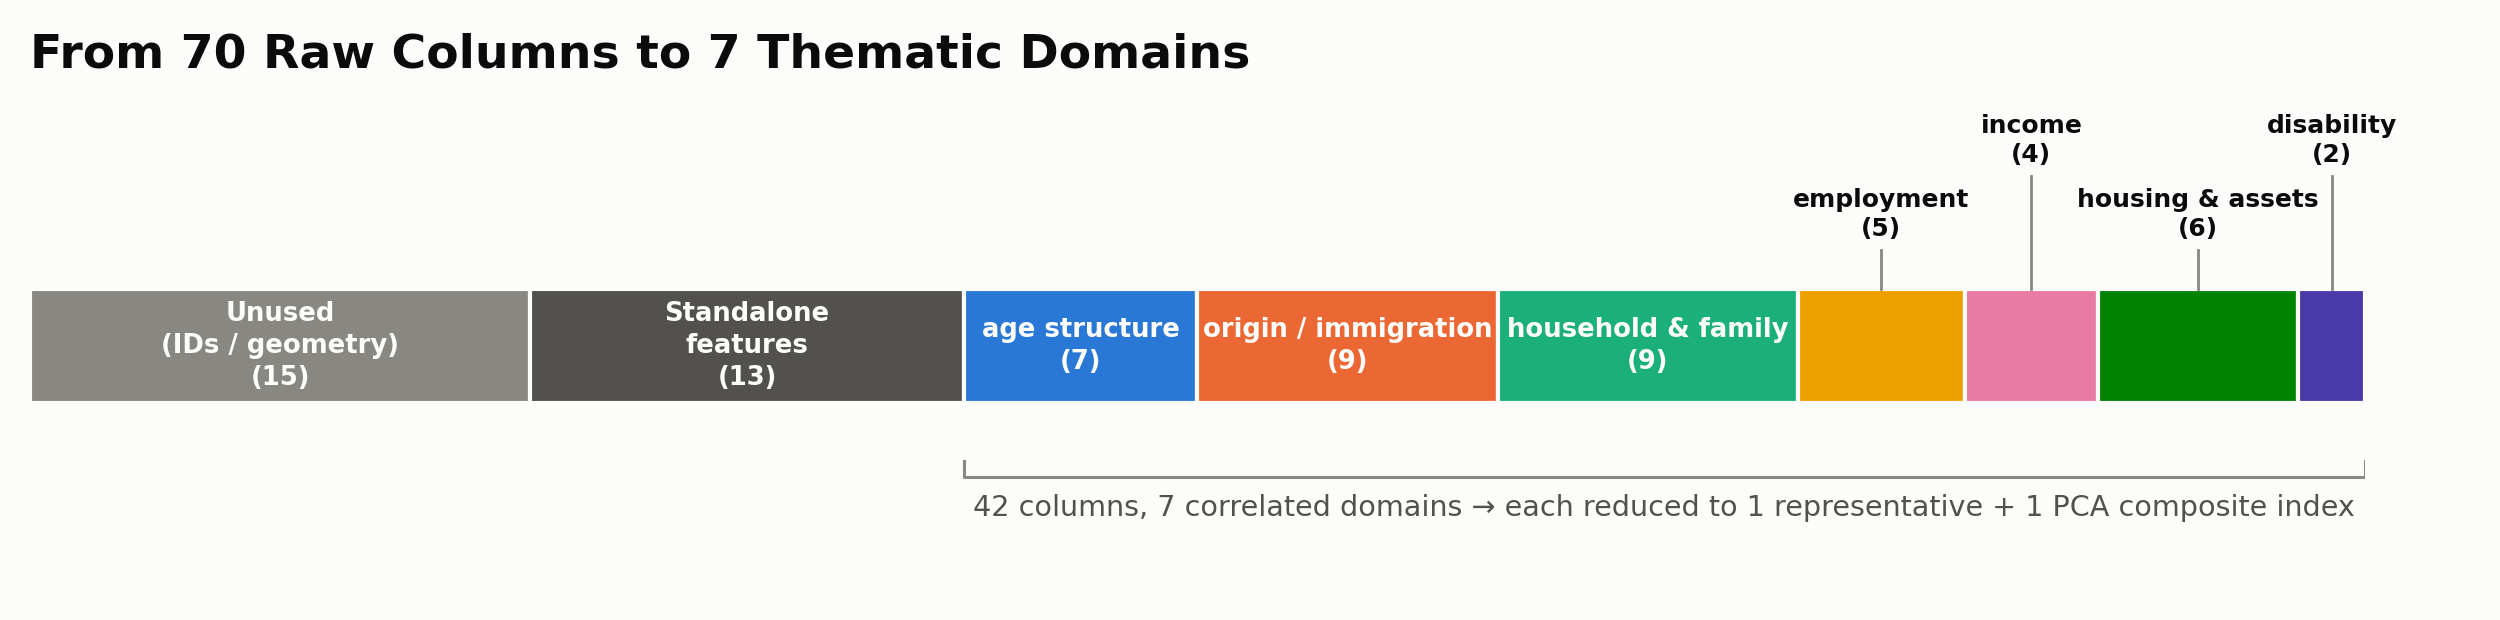

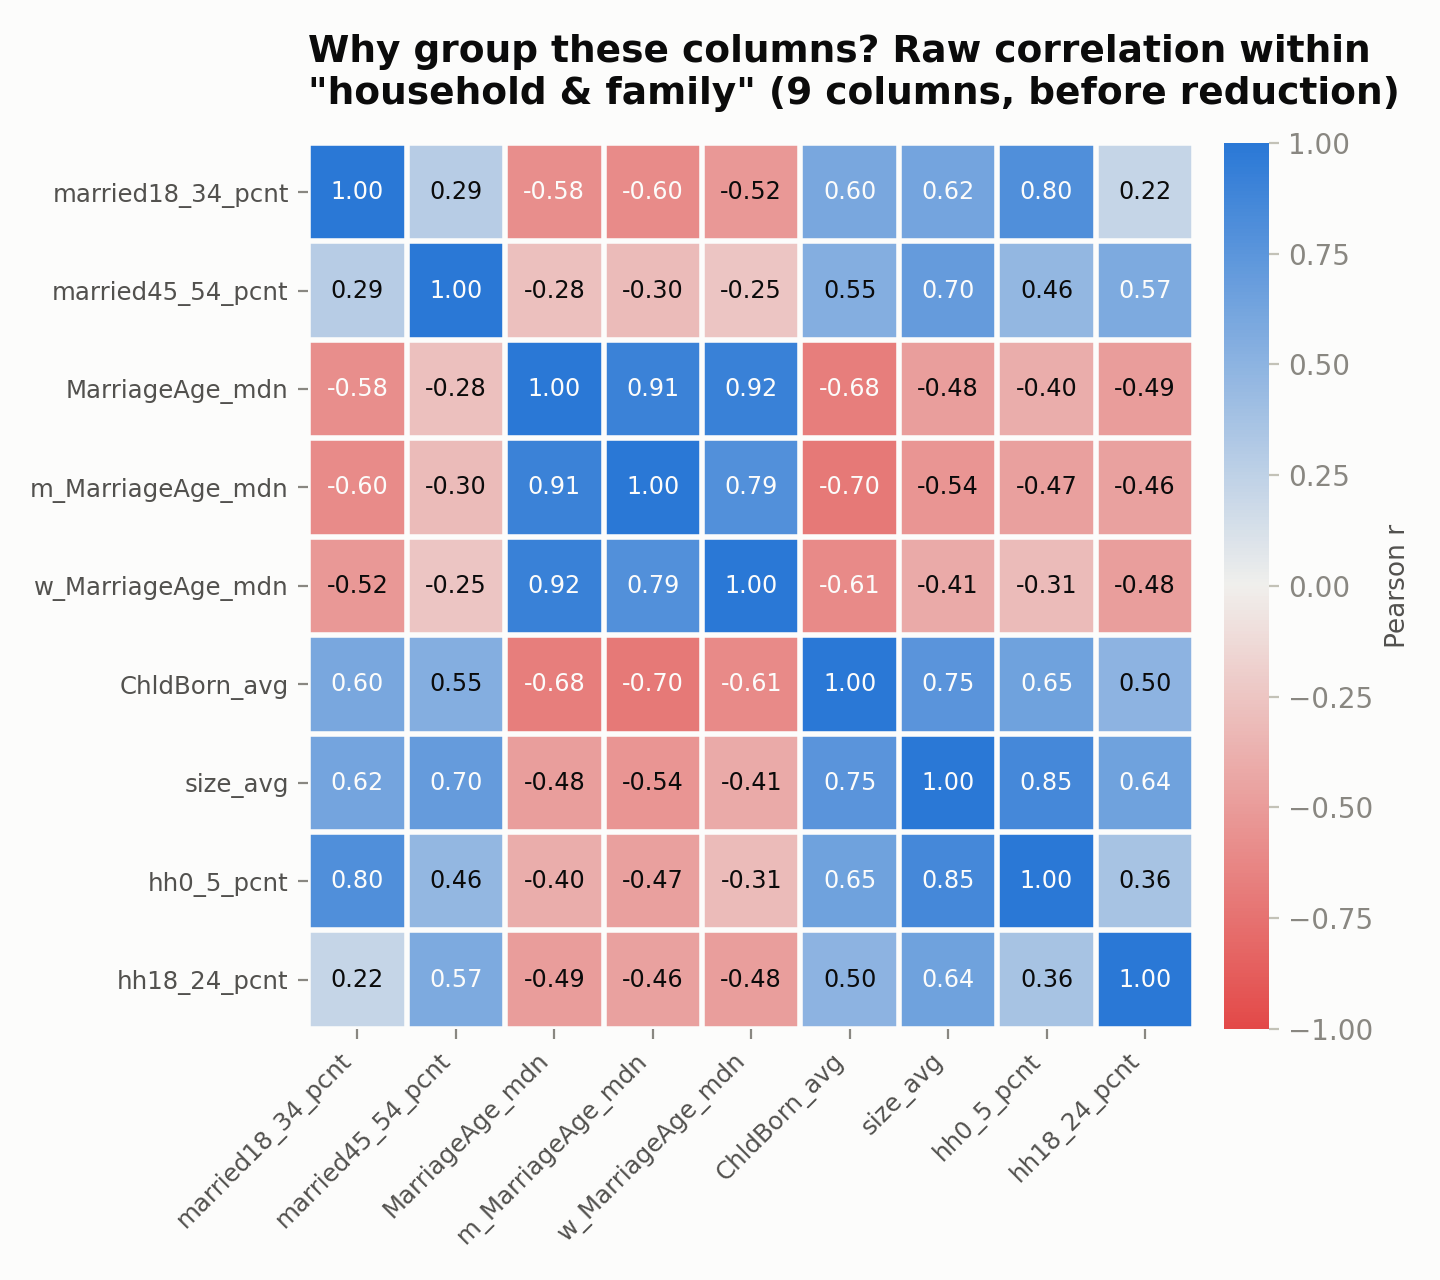

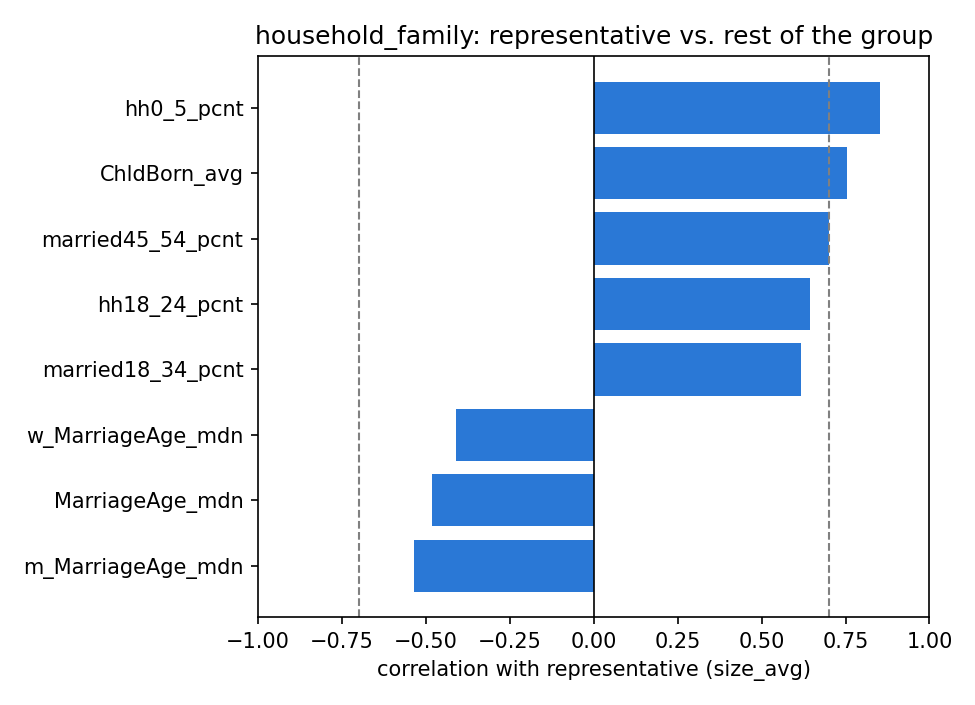

In [40]:
from IPython.display import Image, display
for f in ["census_05_raw_to_domains_flow.png",
          "census_04_domain_correlation_example.png",
          "census_06_representative_corr_household_family.png"]:
    display(Image(filename=f"final_submission/figures/01_data/{f}"))

## 1.5 · Merge A — wave-2 targets ✕ census  → `wave2_model_table.csv`

**Left join** on `City_agas_code` (the wave-2 table is already the filtered set of
data-rich areas), with an explicit `has_census` flag so unmatched areas are visible,
not silently dropped. COVID sub-area codes and 2022-census `StatArea` codes are *not*
the same numbering scheme for a sizeable minority of localities (documented project
limitation) — hence the flag. The modelling table then keeps only `has_census == 1`.

In [41]:
from pathlib import Path
import pandas as pd

CORONA_PATH = Path("data/processed/models/wave2_ir_severity_table.csv")
MIFKAD_PATH = Path("data/processed/mifkad/Mifkad_2_reduced.csv")
OUT_DIR = Path("data/processed/models")
OUT_DIR.mkdir(parents=True, exist_ok=True)

# Running list of (path, description) for every file this notebook saves
output_log = []

def log_output(path, description, description_he):
    output_log.append({"file_path": str(path), "contents": description, "contents_he": description_he})
    print("Saved:", path)

In [42]:
df_corona = pd.read_csv(CORONA_PATH, dtype={"City_agas_code": str})
df_mifkad = pd.read_csv(MIFKAD_PATH, dtype={"City_agas_code": str})

assert df_corona["City_agas_code"].is_unique, "wave2 IR/severity table key is not unique"
assert df_mifkad["City_agas_code"].is_unique, "Mifkad key is not unique - merge would explode rows"

print(f"corona (wave-2 IR/severity): {df_corona.shape[0]:,} areas, {df_corona.shape[1]} cols")
print(f"mifkad (reduced):            {df_mifkad.shape[0]:,} areas, {df_mifkad.shape[1]} cols")

corona (wave-2 IR/severity): 1,595 areas, 10 cols
mifkad (reduced):            4,002 areas, 28 cols


In [43]:
df_merged = df_corona.merge(
    df_mifkad,
    on="City_agas_code",
    how="left",
    validate="one_to_one",
)

df_merged["has_census"] = df_merged["age_structure_idx"].notna().astype(int)

n_total = len(df_merged)
n_with_census = df_merged["has_census"].sum()
print(f"Areas in wave-2 table: {n_total:,}")
print(f"Areas with a census match: {n_with_census:,} ({100 * n_with_census / n_total:.1f}%)")
print(f"Areas without a census match (kept, NaN census columns): {n_total - n_with_census:,}")

Areas in wave-2 table: 1,595
Areas with a census match: 1,008 (63.2%)
Areas without a census match (kept, NaN census columns): 587


In [44]:
unmatched = df_merged.loc[df_merged["has_census"] == 0, ["City_agas_code", "town", "is_city_aggregate"]]

unmatched_path = OUT_DIR / "unmatched_keys_wave2.csv"
unmatched.sort_values("City_agas_code").to_csv(unmatched_path, index=False, encoding="utf-8-sig")

log_output(
    unmatched_path,
    "Areas from the wave-2 IR/severity table with no matching City_agas_code in the reduced "
    "census data. These rows ARE included in wave2_model_table.csv (left join) with NaN census "
    "columns and has_census=0 - this file just lists them for inspection.",
    "אזורים מתוך טבלת ה-IR/חומרה של הגל השני שאין להם City_agas_code מתאים בנתוני המפקד "
    "המצומצמים. השורות האלה כן נכללות ב-wave2_model_table.csv (left join) עם עמודות מפקד "
    "ריקות (NaN) ו-has_census=0 - קובץ זה רק מפרט אותן לבדיקה.",
)

Saved: data/processed/models/unmatched_keys_wave2.csv


In [45]:
merged_path = OUT_DIR / "wave2_model_table.csv"
df_merged.to_csv(merged_path, index=False, encoding="utf-8-sig")

log_output(
    merged_path,
    "Wave-2 (2020-06-01 to 2020-10-31) corona targets left-joined with the reduced census "
    "features (Mifkad_2_reduced.csv) on City_agas_code. One row per area. Corona-side columns: "
    "mean_IR, peak_IR, slope_to_peak_IR, severity_hosp_per_case, is_city_aggregate, "
    "total_tests_in_window, total_cases_in_window, total_hospitalized_in_window (all from "
    "build_wave2_ir_severity_table.py). Census columns repeat the 27 reduced features; unmatched "
    "areas keep NaN census values (has_census=0) instead of being dropped.",
    "יעדי הגל השני (1.6.2020-31.10.2020) ממוזגים (left join) עם נתוני המפקד המצומצמים "
    "(Mifkad_2_reduced.csv) לפי City_agas_code. שורה אחת לכל אזור. עמודות צד-הקורונה: "
    "mean_IR, peak_IR, slope_to_peak_IR, severity_hosp_per_case, is_city_aggregate, "
    "total_tests_in_window, total_cases_in_window, total_hospitalized_in_window (מ-"
    "build_wave2_ir_severity_table.py). עמודות המפקד הן 27 הפיצ'רים המצומצמים; אזורים ללא "
    "התאמה נשארים עם NaN בעמודות המפקד (has_census=0) במקום להיזרק.",
)

Saved: data/processed/models/wave2_model_table.csv


In [46]:
manifest_path = OUT_DIR / "merge_output_files_manifest.csv"
pd.DataFrame(output_log).to_csv(manifest_path, index=False, encoding="utf-8-sig")
print("Saved:", manifest_path)

Saved: data/processed/models/merge_output_files_manifest.csv


In [47]:
n_before = len(df_merged)
df_model = df_merged[df_merged["has_census"] == 1].drop(columns=["has_census"]).reset_index(drop=True)
n_after = len(df_model)

print(f"Rows before filtering to matched areas: {n_before:,}")
print(f"Rows after keeping only has_census==1:   {n_after:,}")
print(f"Rows dropped (no census match):          {n_before - n_after:,}")

df_model.to_csv(merged_path, index=False, encoding="utf-8-sig")

# Replace the earlier (unfiltered) log entry for this same file with the updated description
output_log[:] = [entry for entry in output_log if entry["file_path"] != str(merged_path)]
log_output(
    merged_path,
    "Wave-2 (2020-06-01 to 2020-10-31) corona targets merged with the reduced census features "
    "(Mifkad_2_reduced.csv) on City_agas_code, RESTRICTED to areas with both a corona-side row "
    "and a census match (has_census==1 from the left join above; unmatched areas are excluded "
    "here, listed separately in unmatched_keys_wave2.csv). One row per area. Corona columns: "
    "mean_IR, peak_IR, slope_to_peak_IR, severity_hosp_per_case, is_city_aggregate, "
    "total_tests_in_window, total_cases_in_window, total_hospitalized_in_window. Plus the 27 "
    "reduced census features.",
    "יעדי הגל השני (1.6.2020-31.10.2020) ממוזגים עם נתוני המפקד המצומצמים "
    "(Mifkad_2_reduced.csv) לפי City_agas_code, מוגבל לאזורים עם גם שורת קורונה וגם התאמת "
    "מפקד (has_census==1 מה-left join למעלה; אזורים ללא התאמה מוצאים מכאן, מפורטים בנפרד "
    "ב-unmatched_keys_wave2.csv). שורה אחת לכל אזור. עמודות קורונה: mean_IR, peak_IR, "
    "slope_to_peak_IR, severity_hosp_per_case, is_city_aggregate, total_tests_in_window, "
    "total_cases_in_window, total_hospitalized_in_window. בתוספת 27 פיצ'רי המפקד המצומצמים.",
)

Rows before filtering to matched areas: 1,595
Rows after keeping only has_census==1:   1,008
Rows dropped (no census match):          587
Saved: data/processed/models/wave2_model_table.csv


In [48]:
manifest_path = OUT_DIR / "merge_output_files_manifest.csv"
pd.DataFrame(output_log).to_csv(manifest_path, index=False, encoding="utf-8-sig")
print("Saved:", manifest_path)

Saved: data/processed/models/merge_output_files_manifest.csv


## 1.6 · Merge B — full daily panel ✕ census  → `Corona_Mifkad2_merged.csv`

Same left join, but on the **full daily panel**, and it also derives the two columns
the EDA notebook needs and that need `pop_approx` as a denominator:
`percent_vaccinated_{first,second,third}_dose` and `panic_index` (daily tests per
1,000 residents).

In [49]:
from pathlib import Path
import pandas as pd

CORONA_PATH = Path("data/processed/Corona_loc_processed.csv")
MIFKAD_PATH = Path("data/processed/mifkad/Mifkad_2_reduced.csv")
OUT_PATH = Path("data/processed/Corona_Mifkad2_merged.csv")

# (re-runnable: this notebook overwrites its own processed outputs)

output_log = []

def log_output(path, description, description_he):
    output_log.append({"file_path": str(path), "contents": description, "contents_he": description_he})
    print("Saved:", path)

In [50]:
df_corona = pd.read_csv(CORONA_PATH, dtype={"City_agas_code": str}, parse_dates=["date"])
df_mifkad = pd.read_csv(MIFKAD_PATH, dtype={"City_agas_code": str})

assert df_mifkad["City_agas_code"].is_unique, "Mifkad key is not unique - merge would explode rows"

print(f"corona (daily panel): {df_corona.shape[0]:,} rows, {df_corona['City_agas_code'].nunique():,} areas, "
      f"{df_corona['date'].min().date()} to {df_corona['date'].max().date()}")
print(f"mifkad (reduced): {df_mifkad.shape[0]:,} areas, {df_mifkad.shape[1]} cols")

corona (daily panel): 1,942,906 rows, 1,657 areas, 2020-03-11 to 2023-05-28
mifkad (reduced): 4,002 areas, 28 cols


In [51]:
df_merged = df_corona.merge(
    df_mifkad,
    on="City_agas_code",
    how="left",
    validate="many_to_one",
)

df_merged["has_census"] = df_merged["pop_approx"].notna().astype(int)

n_rows = len(df_merged)
n_areas = df_merged["City_agas_code"].nunique()
n_areas_with_census = df_merged.loc[df_merged["has_census"] == 1, "City_agas_code"].nunique()
print(f"Rows: {n_rows:,}")
print(f"Areas: {n_areas:,} total, {n_areas_with_census:,} with a census match "
      f"({100 * n_areas_with_census / n_areas:.1f}%)")

Rows: 1,942,906
Areas: 1,657 total, 1,197 with a census match (72.2%)


In [52]:
dose_cols = {
    "first": "accumulated_vaccination_first_dose",
    "second": "accumulated_vaccination_second_dose",
    "third": "accumulated_vaccination_third_dose",
}
for dose_name, col in dose_cols.items():
    df_merged[f"percent_vaccinated_{dose_name}_dose"] = 100 * df_merged[col] / df_merged["pop_approx"]

df_merged["panic_index"] = 1000 * df_merged["tested_daily"] / df_merged["pop_approx"]

df_merged[[f"percent_vaccinated_{d}_dose" for d in dose_cols] + ["panic_index"]].describe()

,percent_vaccinated_first_dose,percent_vaccinated_second_dose,percent_vaccinated_third_dose,panic_index
count,1.403670e+06,1.403670e+06,1.403670e+06,1.403670e+06
mean,5.694024e+01,5.197014e+01,3.104774e+01,6.032922e+00
std,5.260543e+01,5.001906e+01,3.939290e+01,1.178415e+01
min,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,3.904382e+00,0.000000e+00,0.000000e+00,6.637168e-01
50%,6.304450e+01,5.726531e+01,2.354839e+01,2.472952e+00
75%,7.695652e+01,7.272544e+01,5.478033e+01,6.920415e+00
max,6.742000e+02,6.327000e+02,4.862903e+02,7.161290e+02


In [53]:
cols_to_drop = [
    "accumulated_vaccination_first_dose",
    "accumulated_vaccination_second_dose",
    "accumulated_vaccination_third_dose",
    "infection_rate_window_days",
    "tested_daily",
]
df_merged = df_merged.drop(columns=cols_to_drop)
print(f"Dropped {len(cols_to_drop)} columns. Remaining: {df_merged.shape[1]} cols")

Dropped 5 columns. Remaining: 49 cols


In [54]:
df_merged.to_csv(OUT_PATH, index=False, encoding="utf-8-sig")

log_output(
    OUT_PATH,
    "Full daily corona panel (Corona_loc_processed.csv) left-joined with the reduced census "
    "(Mifkad_2_reduced.csv, 27 columns) on City_agas_code. One row per area per date. Adds "
    "has_census, percent_vaccinated_first/second/third_dose (from the existing "
    "accumulated_vaccination_*_dose columns / pop_approx), and panic_index (tested_daily per "
    "1,000 residents / pop_approx). Areas with no census match keep has_census=0 and NaN "
    "census/derived columns instead of being dropped. This is Merged_df_PATH in EDA.ipynb.",
    "פאנל הקורונה היומי המלא (Corona_loc_processed.csv) ממוזג (left join) עם המפקד המצומצם "
    "(Mifkad_2_reduced.csv, 27 עמודות) לפי City_agas_code. שורה אחת לכל אזור לכל תאריך. "
    "מתווספות has_census, percent_vaccinated_first/second/third_dose (מעמודות "
    "accumulated_vaccination_*_dose הקיימות חלקי pop_approx), ו-panic_index (tested_daily "
    "ל-1,000 תושבים חלקי pop_approx). אזורים ללא התאמת מפקד נשארים עם has_census=0 ו-NaN "
    "בעמודות המפקד/הנגזרות במקום להיזרק. זהו Merged_df_PATH ב-EDA.ipynb.",
)

manifest_path = OUT_PATH.parent / "merge_full_panel_output_manifest.csv"
pd.DataFrame(output_log).to_csv(manifest_path, index=False, encoding="utf-8-sig")
print("Saved:", manifest_path)

Saved: data/processed/Corona_Mifkad2_merged.csv
Saved: data/processed/merge_full_panel_output_manifest.csv


## Recap

| file | rows | used by |
|------|------|---------|
| `Corona_loc_processed.csv` | daily panel, ~1.3 M | 02 (EDA), 04, 05 |
| `wave2_ir_severity_table.csv` | 1 row/area (wave-2) | 1.5 |
| `Mifkad_2_reduced.csv` | 1 row/area, 27 cols | 1.5, 1.6 |
| `wave2_model_table.csv` | matched areas ✕ (targets + 27 features) | **03 — basic model** |
| `Corona_Mifkad2_merged.csv` | daily panel ✕ census | **02 — EDA** |